In [ ]:
!pip install catboost shap dowhy econml

In [ ]:
import os
import re
from tqdm import tqdm
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import sys
import pandas as pd
import gcsfs
import pyarrow
import catboost
from catboost import CatBoostClassifier
import pyarrow.dataset as ds
import gcsfs
import gc

from google.cloud import bigquery

# Initialize the BigQuery client
client = bigquery.Client()

# Define the table reference, which was used in the previous cell
table_ref = "expanded-nebula-754.sandbox_devanh.pnaModelingInitialData"

# Use the BigQuery client to download the table directly into a DataFrame.
# This is more reliable than exporting to GCS and then reading from GCS.
print("Loading data directly from BigQuery...")
df = client.query(f"SELECT * FROM `{table_ref}`").to_dataframe()

print("Successfully loaded data into a DataFrame.")

Loading data directly from BigQuery...
Successfully loaded data into a DataFrame.


In [ ]:
#other_stock_messaging = ["pna_availability_message_all_other_availability_messages"]
#["total_transactions"]
#["products_pna_checked" ,"total_sessions"]
#df_set['purchase'] = (df_set['total_revenue'] > 0).astype('category')

#from IPython.display import display

#display(list(df.columns))
#display(df.loc[0:3, :])

In [ ]:
discounts = ["pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

no_discount = ["pna_discount_percentage_0"]
#lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
#cat_cols = [['industry']+  ["discount_combo_2sets","set0_category"]][0]#discount_combo_2sets	set0_category
cat_cols = ["industry","discount_combo_2sets","set0_category"]#discount_combo_2sets	set0_category

regressor_cols = ["total_revenue"]
label_cols = ["purchase"]
other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
continuous_cols = in_stock + not_in_stock+ stock_unavailable+ discounts +  no_discount + lead_times +other_cont

#'pna_average_discount_percentage', 'days_diff_transaction', 'days_diff_session', 'pna_lead_time_15to30
all_cols = cat_cols + continuous_cols + regressor_cols + label_cols
print(cat_cols)
print(discounts)
print(no_discount)
print(continuous_cols)
print(len(all_cols))
#print(all_cols)


['industry', 'discount_combo_2sets', 'set0_category']
['pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99']
['pna_discount_percentage_0']
['pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99', 'pna_discoun

In [ ]:
df_set = df[["industry","total_transactions",'total_sessions','order_history_page_views',"sessions_less_than_2_sec","last_session_in_timeframe","first_session_in_timeframe","first_transaction_in_timeframe","last_transaction_in_timeframe","products_pna_checked","pna_availability_message_available_to_ship_on",\
             "pna_availability_message_in_stock","pna_availability_message_from","pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on","pna_average_discount_percentage","pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20",\
             "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50","pna_discount_percentage_51to60","pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90",\
             "pna_discount_percentage_90to99","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove",\
             "total_revenue"]].copy()

#
# removed "industry"
#
#df_set = df[["total_transactions",'total_sessions','order_history_page_views',"sessions_less_than_2_sec","last_session_in_timeframe","first_session_in_timeframe","first_transaction_in_timeframe","last_transaction_in_timeframe","products_pna_checked","pna_availability_message_available_to_ship_on",\
#             "pna_availability_message_in_stock","pna_availability_message_from","pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on","pna_average_discount_percentage","pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20",\
#             "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50","pna_discount_percentage_51to60","pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90",\
#             "pna_discount_percentage_90to99","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove",\
#             "total_revenue"]].copy()
print(len(df_set.columns))


35


In [ ]:
set_0 = ["pna_discount_percentage_0"]
# -----------------------------
set_1 = [
    "pna_discount_percentage_1to10",
    "pna_discount_percentage_11to20",
    "pna_discount_percentage_31to40",
]


set_2 = [
    "pna_discount_percentage_41to50",
    "pna_discount_percentage_51to60",
    "pna_discount_percentage_41to50",
    "pna_discount_percentage_51to60",
    "pna_discount_percentage_61to70",
    "pna_discount_percentage_71to80",
    "pna_discount_percentage_81to90",
    "pna_discount_percentage_90to99",
]
#set_2 = list(dict.fromkeys(set_2_raw))

set_0_col = "pna_discount_percentage_0"

missing = [c for c in (set_1 + set_2 + [set_0_col]) if c not in df_set.columns]
if missing:
    raise KeyError(f"Missing columns in df: {missing}")


eps = 0.001

s1 = df_set[set_1].gt(eps).any(axis=1)
s2 = df_set[set_2].gt(eps).any(axis=1)
code = s1.astype(int) + 2 * s2.astype(int)

combo_map = {0: "none", 1: "only_1", 2: "only_2", 3: "both"}
combo_categories = ["none", "only_1", "only_2", "both"]

df_set["discount_combo_2sets"] = pd.Categorical(
    pd.Series(code).map(combo_map),
    categories=combo_categories,
    ordered=True
)

set0_series = df_set["pna_discount_percentage_0"]

df_set["set0_category"] = pd.Categorical(
    np.where(set0_series.fillna(0) > 0, "no_discount", "unknown"),
    categories=["unknown", "no_discount"],
    ordered=True
)


#df_set['industry'] = df_set['industry'].astype('category')
df_set['discount_combo_2sets'] = df_set['discount_combo_2sets'].astype('category')
df_set['set0_category'] = df_set['set0_category'].astype('category')

df_set['purchase'] = (df_set['total_revenue'] > 0).astype('category')
df_set_filtered = (df_set.loc[df_set["sessions_less_than_2_sec"] > 2].reset_index(drop=True)).copy()
df_set_filtered.drop(columns=["sessions_less_than_2_sec"], inplace=True)

In [ ]:
df_processed = df_set_filtered.copy()

df_processed['first_session_in_timeframe'] = pd.to_datetime(df_processed['first_session_in_timeframe'], errors='coerce')
df_processed['last_session_in_timeframe'] = pd.to_datetime(df_processed['last_session_in_timeframe'], errors='coerce')
df_processed['first_transaction_in_timeframe'] = pd.to_datetime(df_processed['first_transaction_in_timeframe'], errors='coerce')
df_processed['last_transaction_in_timeframe'] = pd.to_datetime(df_processed['last_transaction_in_timeframe'], errors='coerce')

# Second, calculate the date differences. This will result in NaN where dates were missing.
df_processed['days_diff_session'] = (df_processed['last_session_in_timeframe'] - df_processed['first_session_in_timeframe']).dt.days
df_processed['days_diff_transaction'] = (df_processed['last_transaction_in_timeframe'] - df_processed['first_transaction_in_timeframe']).dt.days
df_processed = df_processed.drop(columns=[c for c in  ['first_session_in_timeframe','last_session_in_timeframe','first_transaction_in_timeframe','last_transaction_in_timeframe'] if c in df_set.columns], errors='ignore')#.join(df_weighted).copy()
df_processed.drop(columns=["days_diff_transaction"], inplace=True)

15555
58995


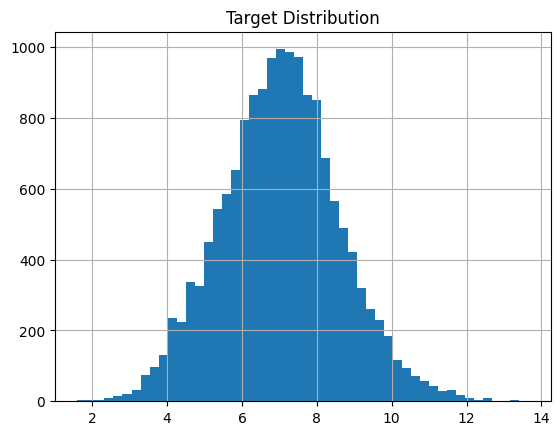

In [ ]:
bought_1 = df_processed[df_processed['total_revenue'] > 0.0].copy() # All samples where bought == 1
bought_0 = df_processed[df_processed['total_revenue'] <= 0.0].copy() # All samples where bought == 0
#bought_0_known['industry'] = bought_0_known['industry'].astype('category')
#bought_0_known['in_stock'] = bought_0_known['in_stock'].astype('category')
#bought_0_known['discount_flag'] = bought_0_known['discount_flag'].astype('category')
#df_filtered = df_set_reduced[df_set_reduced['total_revenue'] > 0.0].copy()
print(len(bought_1))
print(len(bought_0))
y = np.log1p(bought_1[regressor_cols])
import matplotlib.pyplot as plt
y.hist(bins=50)
plt.title("Target Distribution")
plt.show()

In [ ]:
print(len(bought_1.columns))
print(len(all_cols))
l1 = list(bought_0.columns)
l2 = all_cols
difference = list(set(l2) - set(l1))
print(difference)


34
34
[]


In [ ]:
print(cat_cols+continuous_cols)

['industry', 'discount_combo_2sets', 'set0_category', 'pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99', 'pna_discount_percentage_0', 'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7', 'pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_31to59', 'pna_lead_time_60andAbove', 'total_sessions', 'order_history_page_views', 'total_transactions', 'products_pna_checked', 'pna_average_discount_percentage', 'days_diff_session']


(15555, 32)
(15555,)
0:	learn: 1.5232603	test: 1.5492579	best: 1.5492579 (0)	total: 56.1ms	remaining: 44.9s
100:	learn: 0.9498722	test: 0.9851960	best: 0.9851960 (100)	total: 839ms	remaining: 5.81s
200:	learn: 0.9108898	test: 0.9697719	best: 0.9697719 (200)	total: 1.61s	remaining: 4.81s
300:	learn: 0.8815730	test: 0.9648188	best: 0.9647575 (283)	total: 2.38s	remaining: 3.94s
400:	learn: 0.8588277	test: 0.9633155	best: 0.9633155 (400)	total: 3.14s	remaining: 3.13s
500:	learn: 0.8388037	test: 0.9628665	best: 0.9628278 (483)	total: 3.91s	remaining: 2.33s
600:	learn: 0.8217613	test: 0.9626201	best: 0.9625067 (593)	total: 4.68s	remaining: 1.55s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 0.9625067282
bestIteration = 593

Shrink model to first 594 iterations.
Original scale → RMSE: 112,179,667.66 | MAE: 2,934.56 | R^2: 0.6140 | MAPE: 192.17% | sMAPE: 74.84%


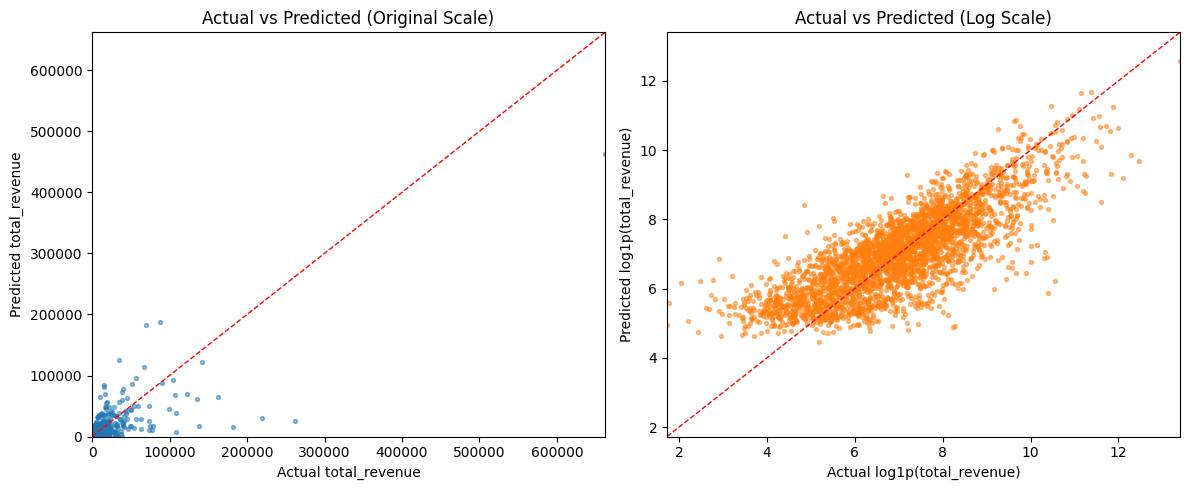

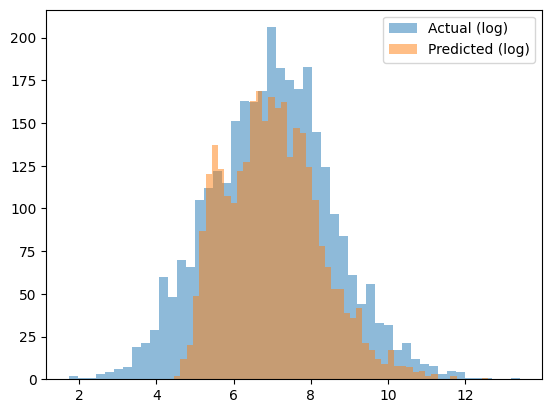

In [ ]:
"""
KeyError: "None of [Index([('industry', 'discount_combo_2sets', 'set0_category', 'pna_availability_message_from', 'pna_availability_message_in_stock',
 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on',
 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40',
  'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80',
   'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99', 'pna_discount_percentage_0', 'pna_lead_time_0', 'pna_lead_time_1to2',
    'pna_lead_time_3to7', 'pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_31to59', 'pna_lead_time_60andAbove',
     'total_sessions', 'order_history_page_views', 'total_transactions', 'products_pna_checked', 'pna_average_discount_percentage', 'days_diff_session')], dtype='object'
"""

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


target = "total_revenue"

# 3) Build X and y (ensure target is numeric and non-negative for log1p)
X = bought_1[cat_cols + continuous_cols].copy()
#X = df_processed[cat_cols + continuous_cols].copy()

print(X.shape)
y_raw = pd.to_numeric(bought_1[target], errors="coerce").fillna(0.0).copy()

# Optional: if negatives can exist, clip to zero (or choose a different transform strategy)
y_raw = y_raw.clip(lower=0)


# 4) Log-transform the target
y_log = np.log1p(y_raw)
print(y_log.shape)
# 5) Split 80/20
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 6) Pools (pass categorical columns by name)
train_pool = Pool(X_train, y_train_log, cat_features=cat_cols)
val_pool   = Pool(X_val,   y_val_log,   cat_features=cat_cols)

# 7) Model
model_reg = CatBoostRegressor(
    iterations=800,
    learning_rate=0.06,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=80
)

model_reg.fit(train_pool, eval_set=val_pool)


preds_val_log = model_reg.predict(X_val)
preds_val = np.expm1(preds_val_log)
y_val = np.expm1(y_val_log)


apply_bias_correction = True
if apply_bias_correction:
    resid_log = y_val_log - preds_val_log
    sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)  # unbiased estimate
    correction = np.exp(0.5 * sigma2)
    preds_val_bc = preds_val * correction
else:
    preds_val_bc = preds_val

# 10) Metrics on original scale
rmse = mean_squared_error(y_val, preds_val_bc)
mae  = mean_absolute_error(y_val, preds_val_bc)
r2   = r2_score(y_val, preds_val_bc)

# MAPE: protect against division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    mape = np.mean(np.abs((y_val - preds_val_bc) / np.where(y_val == 0, np.nan, y_val))) * 100
mape = float(np.nan_to_num(mape, nan=np.inf))  # if many zeros, MAPE can be inf

# SMAPE is often more stable when zeros exist
smape = 100 * np.mean(
    2 * np.abs(preds_val_bc - y_val) / (np.abs(y_val) + np.abs(preds_val_bc) + 1e-12)
)

print(f"Original scale → RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")

# 11) Quick diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Original scale
axes[0].scatter(y_val, preds_val_bc, s=8, alpha=0.5)
lims = [0, max(y_val.max(), preds_val_bc.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title("Actual vs Predicted (Original Scale)")
axes[0].set_xlabel("Actual total_revenue"); axes[0].set_ylabel("Predicted total_revenue")

# (b) Log scale
axes[1].scatter(y_val_log, preds_val_log, s=8, alpha=0.5, color='tab:orange')
lims_log = [min(y_val_log.min(), preds_val_log.min()), max(y_val_log.max(), preds_val_log.max())]
axes[1].plot(lims_log, lims_log, 'r--', linewidth=1)
axes[1].set_xlim(lims_log); axes[1].set_ylim(lims_log)
axes[1].set_title("Actual vs Predicted (Log Scale)")
axes[1].set_xlabel("Actual log1p(total_revenue)"); axes[1].set_ylabel("Predicted log1p(total_revenue)")

plt.tight_layout()
plt.show()
plt.hist(y_val_log, bins=50, alpha=0.5, label="Actual (log)")

plt.hist(preds_val_log, bins=50, alpha=0.5, label="Predicted (log)")
plt.legend()
plt.show()

In [ ]:
gc.collect()
df_processed[regressor_cols] = df_processed[regressor_cols].astype(float)

X = df_processed[all_cols].copy()
y_cls = (df_processed[["total_revenue"]] > 0).astype(int)
y_reg = pd.to_numeric(df_processed["total_revenue"], errors="coerce").fillna(0.0).clip(lower=0)
from IPython.display import display



print([df_processed[regressor_cols].columns])

[Index(['total_revenue'], dtype='object')]


In [ ]:
print( cat_cols + continuous_cols)

['industry', 'discount_combo_2sets', 'set0_category', 'pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99', 'pna_discount_percentage_0', 'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7', 'pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_31to59', 'pna_lead_time_60andAbove', 'total_sessions', 'order_history_page_views', 'total_transactions', 'products_pna_checked', 'pna_average_discount_percentage', 'days_diff_session']


In [ ]:

from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
)
import numpy as np
import pandas as pd


NEG_TO_POS_RATIO = 5     # downsample: keep at most 20x negatives per positive
RANDOM_STATE = 42
USE_BIAS_CORRECTION = True
SEARCH_THRESH_GRID = np.linspace(0.01, 0.80, 40)
bought_0 = bought_0.copy()
bought_1 = bought_1.copy()

bought_0[target] = 0.0
bought_1[target] = pd.to_numeric(bought_1[target], errors="coerce").fillna(0.0).clip(lower=0)

full = pd.concat([bought_0, bought_1], ignore_index=True)

all_cols = cat_cols + continuous_cols
missing = set(all_cols) - set(full.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

X = full[all_cols].copy()
y_cls = (full[target] > 0).astype(int)
y_reg = pd.to_numeric(full[target], errors="coerce").fillna(0.0).clip(lower=0)


def downsample_negatives(X, y_cls, y_reg, neg_to_pos_ratio=20, random_state=42):
    rng = np.random.default_rng(random_state)
    pos_idx = np.where(y_cls == 1)[0]
    neg_idx = np.where(y_cls == 0)[0]
    n_pos = len(pos_idx)
    n_neg_keep = min(len(neg_idx), neg_to_pos_ratio * max(n_pos, 1))
    keep_neg_idx = rng.choice(neg_idx, size=n_neg_keep, replace=False) if n_neg_keep > 0 else np.array([], dtype=int)
    keep_idx = np.concatenate([pos_idx, keep_neg_idx])
    return X.iloc[keep_idx], y_cls.iloc[keep_idx], y_reg.iloc[keep_idx]

X_ds, y_cls_ds, y_reg_ds = downsample_negatives(X, y_cls, y_reg, NEG_TO_POS_RATIO, RANDOM_STATE)

X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X_ds, y_cls_ds, y_reg_ds, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls_ds
)

pos_ratio_full = (y_cls == 1).mean()
class_weights = [1.0, (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)]

clf = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Logloss',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=120,
    class_weights=class_weights
)

clf.fit(
    Pool(X_train, y_train_cls, cat_features=cat_cols),
    eval_set=Pool(X_val, y_val_cls, cat_features=cat_cols)
)

p_pos = clf.predict_proba(X_val)[:, 1]
try:
    auc = roc_auc_score(y_val_cls, p_pos)
    print(f"[Stage 1: Classifier] AUC: {auc:.4f}")
except Exception as e:
    print("[Stage 1: Classifier] AUC not available:", e)

# 8) Stage 2 — Regressor on positives, with log target
pos_train_mask = (y_train_reg > 0)
X_train_pos = X_train[pos_train_mask]
y_train_pos_log = np.log1p(y_train_reg[pos_train_mask])

# Positive subset on validation (for eval & bias correction)
pos_val_mask = (y_val_reg > 0)
X_val_pos = X_val[pos_val_mask]
y_val_pos_log = np.log1p(y_val_reg[pos_val_mask])

regr = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=150,
    l2_leaf_reg=6.0
)

regr.fit(
    Pool(X_train_pos, y_train_pos_log, cat_features=cat_cols),
    eval_set=Pool(X_val_pos, y_val_pos_log, cat_features=cat_cols)
)

yhat_pos_log = regr.predict(X_val)
yhat_pos = np.expm1(yhat_pos_log)
if USE_BIAS_CORRECTION and pos_val_mask.any():
    resid_log = y_val_pos_log - regr.predict(X_val_pos)
    sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)
    bc = float(np.exp(0.5 * sigma2))
else:
    bc = 1.0

yhat_pos_bc = yhat_pos * bc

y_pred_expected = p_pos * yhat_pos_bc


def evaluate_threshold_grid(y_true, yhat_pos_bc, p_pos, grid):
    best = None
    for t in grid:
        y_pred = np.where(p_pos >= t, yhat_pos_bc, 0.0)
        rmse = mean_squared_error(y_true, y_pred)# squared=False)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        if (best is None) or (rmse < best['rmse']):
            best = {'t': float(t), 'rmse': rmse, 'mae': mae, 'r2': r2}
    return best

best_thresh = evaluate_threshold_grid(y_val_reg.values, yhat_pos_bc, p_pos, SEARCH_THRESH_GRID)
y_pred_thresh = np.where(p_pos >= best_thresh['t'], yhat_pos_bc, 0.0)


def report_metrics(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred)#, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    mape = float(np.nan_to_num(mape, nan=np.inf))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-12))
    print(f"{name:>24} → RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")

# Baselines
y_zero = np.zeros_like(y_val_reg)
y_mean = np.full_like(y_val_reg, fill_value=y_train_reg.mean(), dtype=float)

print("\n=== Baselines ===")
report_metrics("Always Zero", y_val_reg, y_zero)
report_metrics("Global Mean", y_val_reg, y_mean)

print("\n=== Two-Stage Results ===")
report_metrics("Expected Value (p * y+)", y_val_reg, y_pred_expected)
print(f"Best threshold for RMSE: t = {best_thresh['t']:.3f}")
report_metrics("Thresholded (best t)",   y_val_reg, y_pred_thresh)

0:	learn: 0.4855079	test: 0.4854047	best: 0.4854047 (0)	total: 44.5ms	remaining: 53.3s
100:	learn: 0.0000996	test: 0.0001175	best: 0.0001175 (100)	total: 3.15s	remaining: 34.3s
200:	learn: 0.0000867	test: 0.0001047	best: 0.0001047 (197)	total: 5.94s	remaining: 29.5s
300:	learn: 0.0000866	test: 0.0001046	best: 0.0001046 (300)	total: 8.28s	remaining: 24.7s
400:	learn: 0.0000866	test: 0.0001046	best: 0.0001046 (310)	total: 10.4s	remaining: 20.7s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.0001045905285
bestIteration = 310

Shrink model to first 311 iterations.
[Stage 1: Classifier] AUC: 1.0000
0:	learn: 1.5359527	test: 1.5393031	best: 1.5393031 (0)	total: 8.85ms	remaining: 13.3s
100:	learn: 0.9634673	test: 0.9859553	best: 0.9859553 (100)	total: 785ms	remaining: 10.9s
200:	learn: 0.9333047	test: 0.9696503	best: 0.9696503 (200)	total: 1.58s	remaining: 10.2s
300:	learn: 0.9073524	test: 0.9607910	best: 0.9607757 (299)	total: 2.36s	remaining: 9.39s
400:	learn: 0.887602

In [ ]:
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import gc
del df
gc.collect()

bought_0['total_revenue'] = 0.0  # ensure target exists
full_data = pd.concat([bought_0, bought_1], ignore_index=True)

X = full_data[cat_cols + continuous_cols].copy()
y_cls = (full_data["total_revenue"] > 0).astype(int)  # 1 = positive revenue
y_reg = full_data["total_revenue"].clip(lower=0)

X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)

pos_ratio = y_train_cls.mean()
class_weights = [1.0, (1.0 - pos_ratio) / (pos_ratio + 1e-12)]  # roughly n_neg/n_pos

clf = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=4,
    loss_function='Logloss',
    eval_metric='Logloss',
    random_state=42,
    verbose=100,
    early_stopping_rounds=100,
    class_weights=class_weights
)
print(cat_cols)
clf.fit(
    Pool(X_train, y_train_cls, cat_features=cat_cols),
    eval_set=Pool(X_val, y_val_cls, cat_features=cat_cols)
)

p_val = clf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val_cls, p_val)
print(f"[Stage 1: Classifier] AUC: {auc:.4f}")

pos_train_mask = (y_train_reg > 0)
X_train_pos = X_train[pos_train_mask]
y_train_pos_log = np.log1p(y_train_reg[pos_train_mask])

pos_val_mask = (y_val_reg > 0)
X_val_pos = X_val[pos_val_mask]
y_val_pos_log = np.log1p(y_val_reg[pos_val_mask])

regr = CatBoostRegressor(
    iterations=800,
    learning_rate=0.06,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=80
)

regr.fit(
    Pool(X_train_pos, y_train_pos_log, cat_features=cat_cols),
    eval_set=Pool(X_val_pos, y_val_pos_log, cat_features=cat_cols)
)
p_pos = clf.predict_proba(X_val)[:, 1]
yhat_pos_log = regr.predict(X_val)
yhat_pos = np.expm1(yhat_pos_log)

y_pred_expected = p_pos * yhat_pos

rmse = mean_squared_error(y_val_reg, y_pred_expected)#, squared=False)
mae  = mean_absolute_error(y_val_reg, y_pred_expected)
r2   = r2_score(y_val_reg, y_pred_expected)
print(f"[Two-Stage Expected] RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f}")

['industry', 'discount_combo_2sets', 'set0_category']
0:	learn: 0.6471382	test: 0.6471154	best: 0.6471154 (0)	total: 31.9ms	remaining: 31.8s
100:	learn: 0.0018543	test: 0.0018440	best: 0.0018440 (100)	total: 2.71s	remaining: 24.1s
200:	learn: 0.0003023	test: 0.0003006	best: 0.0003006 (199)	total: 4.87s	remaining: 19.3s
300:	learn: 0.0002759	test: 0.0002744	best: 0.0002744 (298)	total: 6.63s	remaining: 15.4s
400:	learn: 0.0002759	test: 0.0002744	best: 0.0002744 (400)	total: 8.42s	remaining: 12.6s
500:	learn: 0.0002759	test: 0.0002744	best: 0.0002744 (500)	total: 10.2s	remaining: 10.1s
600:	learn: 0.0002759	test: 0.0002744	best: 0.0002744 (600)	total: 11.9s	remaining: 7.88s
700:	learn: 0.0002710	test: 0.0002695	best: 0.0002695 (700)	total: 13.7s	remaining: 5.82s
800:	learn: 0.0002710	test: 0.0002695	best: 0.0002695 (800)	total: 15.4s	remaining: 3.83s
900:	learn: 0.0002710	test: 0.0002695	best: 0.0002695 (900)	total: 17.1s	remaining: 1.88s
999:	learn: 0.0002710	test: 0.0002695	best: 0.000

In [ ]:
gc.collect()

bought_0.drop(columns=['purchase'], inplace=True)
bought_1.drop(columns=['purchase'], inplace=True)

In [ ]:

bought_0[cat_cols[0]] = bought_0[cat_cols[0]].astype('category')
bought_0[cat_cols[1]] = bought_0[cat_cols[1]].astype('category')
bought_0[cat_cols[2]] = bought_0[cat_cols[2]].astype('category')
bought_1[cat_cols[0]] = bought_1[cat_cols[0]].astype('category')
bought_1[cat_cols[1]] = bought_1[cat_cols[1]].astype('category')
bought_1[cat_cols[2]] = bought_1[cat_cols[2]].astype('category')

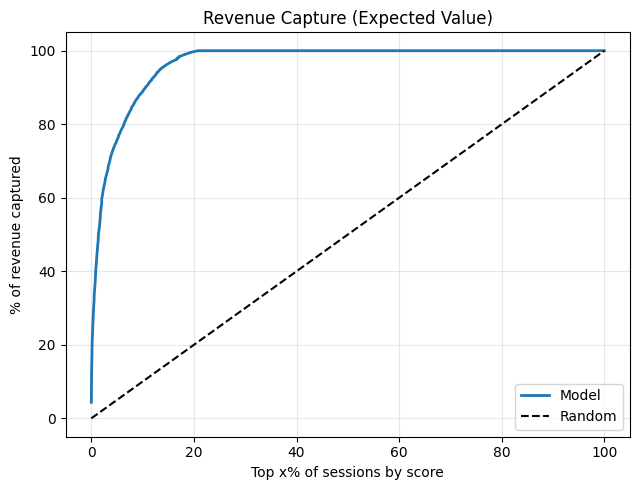


Revenue capture @K% using Expected Value ranking:
Top  1% → capture  42.79% of revenue | lift 42.79×
Top  2% → capture  58.14% of revenue | lift 29.07×
Top  5% → capture  75.75% of revenue | lift 15.15×
Top 10% → capture  88.93% of revenue | lift 8.89×
Top 20% → capture  99.77% of revenue | lift 4.99×
Top 30% → capture 100.00% of revenue | lift 3.33×
Top 50% → capture 100.00% of revenue | lift 2.00×


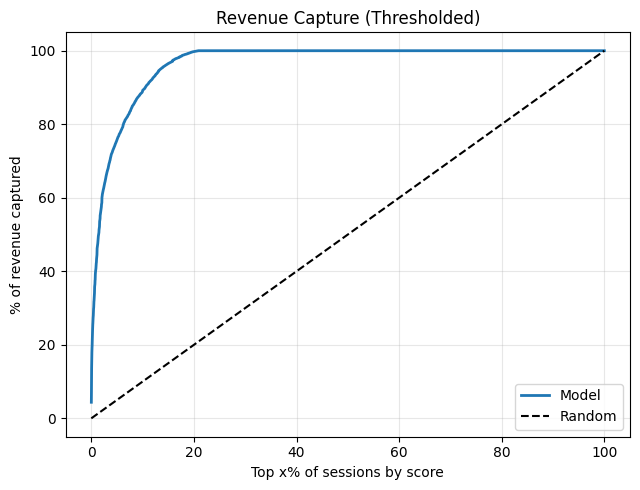


Revenue capture @K% using Thresholded ranking:
Top  1% → capture  42.95% of revenue | lift 42.95×
Top  2% → capture  58.26% of revenue | lift 29.13×
Top  5% → capture  75.85% of revenue | lift 15.17×
Top 10% → capture  89.09% of revenue | lift 8.91×
Top 20% → capture  99.76% of revenue | lift 4.99×
Top 30% → capture 100.00% of revenue | lift 3.33×
Top 50% → capture 100.00% of revenue | lift 2.00×


4111

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def revenue_capture_curve(y_true, score, ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00),
                          title="Revenue Capture Curve", show_plot=True):
    """
    Computes revenue capture @K% and lift, and (optionally) plots the capture curve.
    - y_true: array-like of actual revenues (original scale)
    - score:  array-like of ranking score (e.g., predicted expected revenue)
    - ks:     tuple/list of top-% cutoffs to report (fractions: 0..1)
    Returns:
      captures: dict[k] -> {'captured_pct': float(0..100), 'lift': float}
      curve_df: DataFrame with 'percentile' (0..1) and 'cum_capture_pct' (0..1)
    """
    df = pd.DataFrame({'y': np.asarray(y_true), 'score': np.asarray(score)}).copy()
    n = len(df)
    if n == 0:
        raise ValueError("Empty inputs to revenue_capture_curve.")
    total_rev = df['y'].sum()
    if total_rev <= 0:
        print("Warning: total revenue in y_true is 0 — capture metrics are not meaningful.")
        total_rev = 1e-12  # avoid divide-by-zero; results will be ~0

    # Sort by score descending (best to worst)
    df = df.sort_values('score', ascending=False).reset_index(drop=True)

    # Cumulative revenue and capture%
    df['cum_revenue'] = df['y'].cumsum()
    df['percentile'] = (np.arange(n) + 1) / n  # 0..1 by rank position
    df['cum_capture_pct'] = df['cum_revenue'] / total_rev  # 0..1

    # Report capture at requested ks
    captures = {}
    for k in ks:
        top = max(1, int(np.ceil(k * n)))
        captured = df.loc[:top-1, 'y'].sum() / total_rev
        lift = (captured / k) if k > 0 else np.nan
        captures[float(k)] = {'captured_pct': captured * 100.0, 'lift': lift}

    # Plot curve
    if show_plot:
        plt.figure(figsize=(6.5, 5))
        plt.plot(df['percentile'] * 100, df['cum_capture_pct'] * 100, label='Model', linewidth=2)
        plt.plot([0, 100], [0, 100], 'k--', label='Random')
        plt.xlabel('Top x% of sessions by score')
        plt.ylabel('% of revenue captured')
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return captures, df[['percentile', 'cum_capture_pct']]

# -----------------------------
# Run revenue capture analysis
# -----------------------------

# Choose the ranking score: expected revenue is typically best for targeting
score_ev = y_pred_expected

# 1) Revenue capture for Expected Value (p × y+)
caps_ev, curve_ev = revenue_capture_curve(
    y_true=y_val_reg,
    score=score_ev,
    ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00),
    title="Revenue Capture (Expected Value)",
    show_plot=True
)

print("\nRevenue capture @K% using Expected Value ranking:")
for k in [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    c = caps_ev[k]
    print(f"Top {int(k*100):>2}% → capture {c['captured_pct']:6.2f}% of revenue | lift {c['lift']:.2f}×")

# 2) (Optional) Compare with Thresholded predictions as ranking score
#    Note: Thresholded scores are mostly 0 or positive amounts. Ranking may be coarser than EV.
try:
    caps_th, curve_th = revenue_capture_curve(
        y_true=y_val_reg,
        score=y_pred_thresh,
        ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00),
        title="Revenue Capture (Thresholded)",
        show_plot=True
    )

    print("\nRevenue capture @K% using Thresholded ranking:")
    for k in [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
        c = caps_th[k]
        print(f"Top {int(k*100):>2}% → capture {c['captured_pct']:6.2f}% of revenue | lift {c['lift']:.2f}×")
except NameError:
    print("\n[Info] y_pred_thresh not found; skipping thresholded capture analysis.")


gc.collect()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1) Inequality metrics
# -------------------------
def gini_coefficient(y):
    """Gini for non-negative y. Returns 0 if all zeros/empty."""
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    if len(y) == 0:
        return np.nan
    y = np.clip(y, 0, None)
    s = y.sum()
    if s == 0:
        return 0.0
    y_sorted = np.sort(y)
    n = len(y_sorted)
    i = np.arange(1, n + 1)
    g = (2.0 * np.sum(i * y_sorted)) / (n * s) - (n + 1) / n
    return float(g)

def lorenz_points(y):
    """Lorenz curve points (x: population share 0..1, L: cumulative revenue share 0..1)."""
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    y = np.clip(y, 0, None)
    n = len(y)
    if n == 0 or y.sum() == 0:
        # Flat line at 0, except last point at 1 if sum==0 is undefined—keep zero to avoid confusion
        return np.linspace(0, 1, 2), np.array([0.0, 0.0])
    y_sorted = np.sort(y)
    cum_y = np.cumsum(y_sorted)
    L = np.insert(cum_y, 0, 0) / cum_y[-1]  # cumulative share (0..1), prepend 0
    x = np.linspace(0, 1, len(L))           # equally spaced population share
    return x, L

def plot_lorenz(y, title="Revenue Lorenz Curve"):
    x, L = lorenz_points(y)
    g = gini_coefficient(y)
    plt.figure(figsize=(6, 5))
    plt.plot(x * 100, L * 100, label=f'Lorenz (Gini={g:.2f})', linewidth=2)
    plt.plot([0, 100], [0, 100], 'k--', label='Equality')
    plt.xlabel('Bottom x% of units')
    plt.ylabel('Cumulative % of revenue')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return g

def plot_revenue_distribution(y, unit_label="sessions", title_prefix="Revenue"):
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    y = np.clip(y, 0, None)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    # Right-skewed distributions: plot linear and log-scale
    axes[0].hist(y[y > 0], bins=60, color="#4e79a7")
    axes[0].set_title(f"{title_prefix} distribution ({unit_label}, linear)")
    axes[0].set_xlabel('Revenue')
    axes[0].set_ylabel('Count')
    axes[0].grid(alpha=0.2)

    axes[1].hist(np.log10(y[y > 0] + 1), bins=60, color="#f28e2b")
    axes[1].set_title(f"{title_prefix} distribution ({unit_label}, log10-scale)")
    axes[1].set_xlabel('log10(Revenue + 1)')
    axes[1].set_ylabel('Count')
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

def top_share(y, q=0.01):
    """
    Share of total revenue contributed by the top q fraction of units,
    ranked by actual revenue (not by the model).
    """
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    y = np.clip(y, 0, None)
    n = len(y)
    if n == 0 or y.sum() == 0:
        return np.nan
    k = max(1, int(np.ceil(q * n)))
    y_sorted = np.sort(y)[::-1]
    return float(y_sorted[:k].sum() / y_sorted.sum())

# -------------------------------------
# 2) Revenue capture curve (enhanced)
# -------------------------------------
def revenue_capture_curve(y_true,
                          score,
                          ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00),
                          title="Revenue Capture Curve",
                          show_plot=True,
                          unit_label="sessions",
                          # Whale handling
                          cap_quantile=None,   # e.g., 0.99 to winsorize at 99th pct of y
                          cap_value=None,      # absolute cap on y (applied after quantile if both set)
                          # Customer-level option
                          group_ids=None,      # e.g., session_customer_id (same length as y_true)
                          score_agg="max"      # how to aggregate scores per customer: 'max'|'mean'|'sum'
                          ):
    """
    Computes revenue capture @K% and lift, optionally with revenue capping and/or customer aggregation.
    Returns: captures (dict), curve_df (DataFrame with percentile & cum_capture_pct).
    """
    df = pd.DataFrame({
        'y': np.asarray(y_true, dtype=float),
        'score': np.asarray(score, dtype=float)
    }).copy()

    if len(df) == 0:
        raise ValueError("Empty inputs to revenue_capture_curve.")

    # Clean
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['y', 'score'])
    df['y'] = np.clip(df['y'], 0, None)

    # Apply capping (winsorization) on y
    y_cap = df['y'].values.copy()
    if cap_quantile is not None:
        qv = np.nanquantile(y_cap, cap_quantile)
        y_cap = np.minimum(y_cap, qv)
    if cap_value is not None:
        y_cap = np.minimum(y_cap, cap_value)
    df['y_cap'] = y_cap

    # Aggregate to customer (optional)
    if group_ids is not None:
        df['group'] = np.asarray(group_ids)
        agg_funcs = {'y_cap': 'sum'}
        if score_agg == 'max':
            score_series = df.groupby('group')['score'].max()
        elif score_agg == 'mean':
            score_series = df.groupby('group')['score'].mean()
        elif score_agg == 'sum':
            score_series = df.groupby('group')['score'].sum()
        else:
            raise ValueError("score_agg must be one of: 'max','mean','sum'")
        revenue_series = df.groupby('group')['y_cap'].sum()
        rank_df = pd.DataFrame({'y': revenue_series, 'score': score_series}).reset_index(drop=True)
        plot_unit = "customers" if unit_label == "sessions" else unit_label
    else:
        rank_df = df[['y_cap', 'score']].rename(columns={'y_cap': 'y'}).copy()
        plot_unit = unit_label

    n = len(rank_df)
    if n == 0:
        raise ValueError("No valid rows after cleaning/aggregation.")

    total_rev = rank_df['y'].sum()
    if total_rev <= 0:
        print("Warning: total revenue is 0 after capping/aggregation — metrics not meaningful.")
        total_rev = 1e-12

    # Sort by score desc
    rank_df = rank_df.sort_values('score', ascending=False).reset_index(drop=True)

    # Cumulative capture curve
    rank_df['cum_revenue'] = rank_df['y'].cumsum()
    rank_df['percentile'] = (np.arange(n) + 1) / n
    rank_df['cum_capture_pct'] = (rank_df['cum_revenue'] / total_rev)  # 0..1

    # Capture table at ks
    captures = {}
    for k in ks:
        top = max(1, int(np.ceil(k * n)))
        captured = rank_df.loc[:top - 1, 'y'].sum() / total_rev
        lift = (captured / k) if (k > 0) else np.nan
        captures[float(k)] = {'captured_pct': captured * 100.0, 'lift': float(lift)}

    # Plot
    if show_plot:
        plt.figure(figsize=(6.5, 5))
        plt.plot(rank_df['percentile'] * 100, rank_df['cum_capture_pct'] * 100,
                 label='Model', linewidth=2)
        plt.plot([0, 100], [0, 100], 'k--', label='Random')
        plt.xlabel(f'Top x% of {plot_unit} by score')
        plt.ylabel('% of revenue captured')
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return captures, rank_df[['percentile', 'cum_capture_pct']]

# -------------------------------------
# 3) Convenience: compare multiple caps
# -------------------------------------
def compare_caps(y_true, score, cap_quantiles=(None, 0.999, 0.995, 0.99),
                 labels=None, colors=None, unit_label='sessions',
                 group_ids=None, score_agg='max', title='Capture vs. caps'):
    """
    Plots capture curves for several cap quantiles on one chart.
    cap_quantiles: iterable including None (no cap) and quantiles in (0,1).
    """
    curves = []
    if labels is None:
        labels = [("No cap" if q is None else f"Cap @ {int(q*1000)/10:.1f}th pct") for q in cap_quantiles]
    if colors is None:
        colors = [None] * len(cap_quantiles)

    plt.figure(figsize=(6.8, 5.2))
    for q, lab, col in zip(cap_quantiles, labels, colors):
        caps, curve = revenue_capture_curve(
            y_true=y_true, score=score, show_plot=False,
            unit_label=unit_label, cap_quantile=q,
            group_ids=group_ids, score_agg=score_agg
        )
        curves.append((q, caps, curve))
        plt.plot(curve['percentile'] * 100, curve['cum_capture_pct'] * 100,
                 label=lab, linewidth=2, color=col)

    # Random baseline
    plt.plot([0, 100], [0, 100], 'k--', label='Random')
    plt.xlabel(f'Top x% of {("customers" if group_ids is not None else unit_label)} by score')
    plt.ylabel('% of revenue captured')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return curves

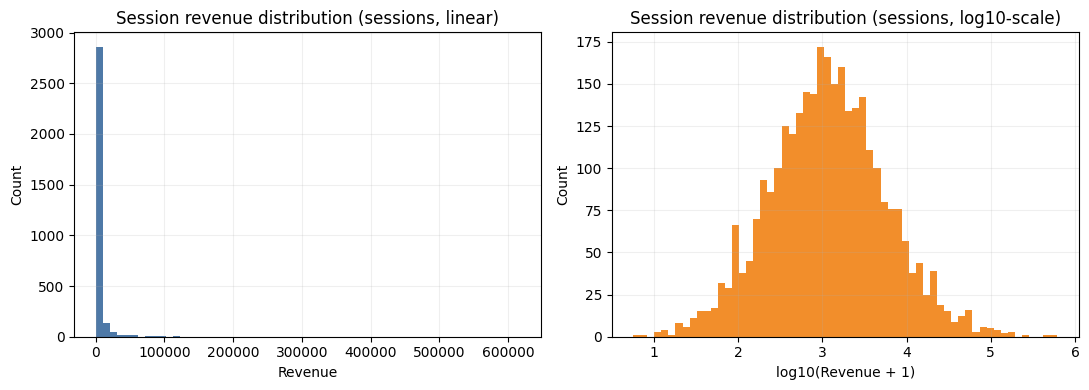

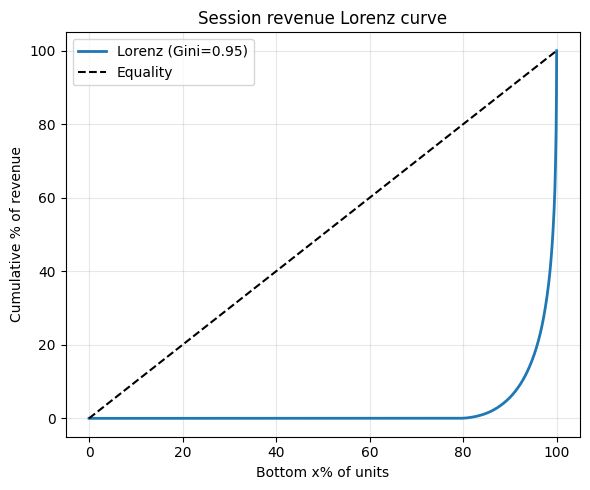

Gini (sessions) = 0.952
Top 0.10% sessions hold 20.8% of revenue
Top 0.50% sessions hold 42.2% of revenue
Top 1.00% sessions hold 53.7% of revenue
Top 5.00% sessions hold 83.4% of revenue


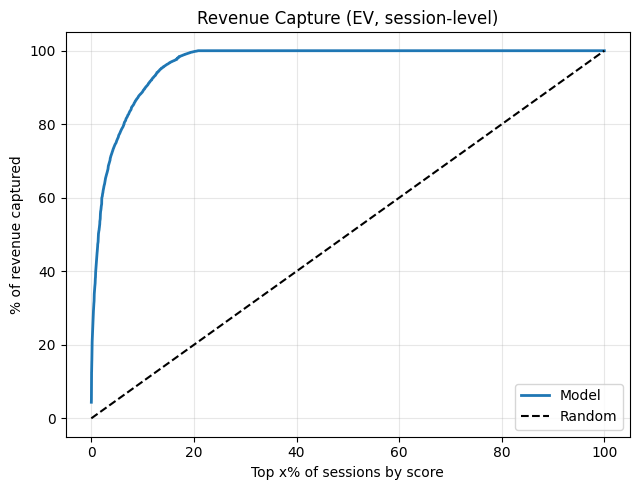


Revenue capture @K% (EV, session-level):
Top  1% → capture  42.79% of revenue | lift 42.79×
Top  2% → capture  58.14% of revenue | lift 29.07×
Top  5% → capture  75.75% of revenue | lift 15.15×
Top 10% → capture  88.93% of revenue | lift 8.89×
Top 20% → capture  99.77% of revenue | lift 4.99×
Top 30% → capture 100.00% of revenue | lift 3.33×
Top 50% → capture 100.00% of revenue | lift 2.00×


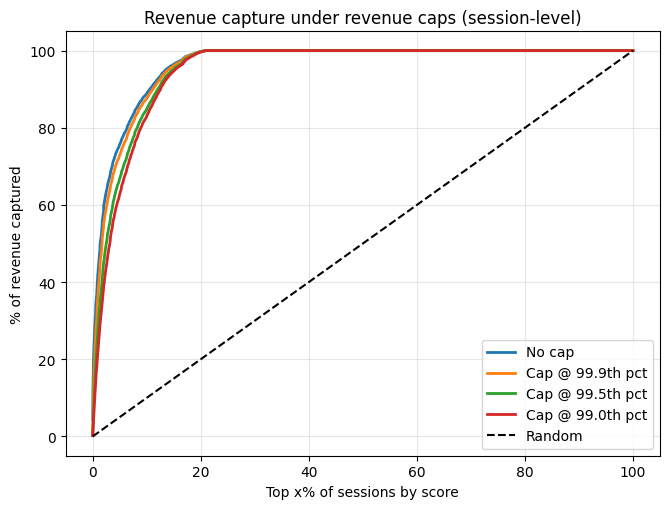

In [ ]:
# (a) Distribution (linear & log-scale)
plot_revenue_distribution(y_val_reg, unit_label="sessions", title_prefix="Session revenue")

# (b) Lorenz + Gini
gini = plot_lorenz(y_val_reg, title="Session revenue Lorenz curve")
print(f"Gini (sessions) = {gini:.3f}")

# (c) Whale dominance diagnostics
for q in [0.001, 0.005, 0.01, 0.05]:
    share = top_share(y_val_reg, q)
    print(f"Top {q*100:.2f}% sessions hold {share*100:.1f}% of revenue")

caps_ev, curve_ev = revenue_capture_curve(
    y_true=y_val_reg,
    score=y_pred_expected,
    unit_label="sessions",
    title="Revenue Capture (EV, session-level)",
    show_plot=True
)

print("\nRevenue capture @K% (EV, session-level):")
for k in [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    c = caps_ev[k]
    print(f"Top {int(k*100):>2}% → capture {c['captured_pct']:6.2f}% of revenue | lift {c['lift']:.2f}×")


_ = compare_caps(
    y_true=y_val_reg,
    score=y_pred_expected,
    cap_quantiles=(None, 0.999, 0.995, 0.99),
    unit_label="sessions",
    title="Revenue capture under revenue caps (session-level)")

In [ ]:
print(cat_cols)

['industry', 'discount_combo_2sets', 'set0_category']


In [ ]:

full[cat_cols] = full[cat_cols].astype('category')
print(full.dtypes)

industry                                                category
total_transactions                                         Int64
total_sessions                                             Int64
order_history_page_views                                   Int64
products_pna_checked                                       Int64
pna_availability_message_available_to_ship_on              Int64
pna_availability_message_in_stock                          Int64
pna_availability_message_from                              Int64
pna_availability_message_check_cart_for_availability       Int64
pna_availability_message_estimated_to_ship_on              Int64
pna_average_discount_percentage                          float64
pna_discount_percentage_0                                  Int64
pna_discount_percentage_1to10                              Int64
pna_discount_percentage_11to20                             Int64
pna_discount_percentage_21to30                             Int64
pna_discount_percentage_3

In [ ]:
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
)
import numpy as np
import pandas as pd

discounts = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

no_discount = ["pna_discount_percentage_0"]
#lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
#cat_cols = [['industry']+  ["discount_combo_2sets","set0_category"]][0]#discount_combo_2sets	set0_category
cat_cols = ["industry","discount_combo_2sets","set0_category"]
regressor_cols = ["total_revenue"]
label_cols = ["purchase"]

other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
continuous_cols = in_stock + not_in_stock+ stock_unavailable+ discounts  +lead_times + other_cont
all_cols = regressor_cols + cat_cols + continuous_cols
target = "purchase"

NEG_TO_POS_RATIO = 20     # downsample: keep at most 20x negatives per positive
RANDOM_STATE = 42
USE_BIAS_CORRECTION = True
SEARCH_THRESH_GRID = np.linspace(0.01, 0.80, 40)
#bought_0 = bought_0.copy()
#bought_1 = bought_1.copy()

#bought_0[target] = 0.0
full = df_processed.copy()
full[target] = pd.to_numeric(full[target], errors="coerce").fillna(0.0).clip(lower=0)


#full = pd.concat([bought_0, bought_1], ignore_index=True)

all_cols = cat_cols + continuous_cols
missing = set(all_cols) - set(full.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

X = full[all_cols].copy()
y_cls = (full[["total_revenue"]] > 0).astype(int)
y_reg = pd.to_numeric(full["total_revenue"], errors="coerce").fillna(0.0).clip(lower=0)


def downsample_negatives(X, y_cls, y_reg, neg_to_pos_ratio=20, random_state=42):
    rng = np.random.default_rng(random_state)
    pos_idx = np.where(y_cls == 1)[0]
    neg_idx = np.where(y_cls == 0)[0]
    n_pos = len(pos_idx)
    n_neg_keep = min(len(neg_idx), neg_to_pos_ratio * max(n_pos, 1))
    keep_neg_idx = rng.choice(neg_idx, size=n_neg_keep, replace=False) if n_neg_keep > 0 else np.array([], dtype=int)
    keep_idx = np.concatenate([pos_idx, keep_neg_idx])
    return X.iloc[keep_idx], y_cls.iloc[keep_idx], y_reg.iloc[keep_idx]

#X_ds, y_cls_ds, y_reg_ds = downsample_negatives(X, y_cls, y_reg, NEG_TO_POS_RATIO, RANDOM_STATE)

#X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
#    X_ds, y_cls_ds, y_reg_ds, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls_ds
#)
X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=RANDOM_STATE#, stratify=y_reg
)
##print(y_cls.shape)
#pos_ratio_full = (y_cls == 1).mean()
##print(pos_ratio_full.shape)
#w = (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)
##print(w.shape)
#class_weights = [1.0, (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)]
#print(class_weights[1])
#class_weights = [1.0, w]
#print(class_weights[1])
# Example: y_train is 0/1
pos_ratio_full = float(y_train_cls.mean())  # ensure scalar
w_pos = (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)  # relative to w_neg = 1.0

class_weights = [1.0, float(w_pos)]  # NOT a string, and not a nested list



# 7) Stage 1 — Classifier on positives
clf = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.05,
    depth=5,
    loss_function='Logloss',
    eval_metric='Logloss',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=120,
   # class_weights=class_weights
)

clf.fit(
    Pool(X_train, y_train_cls, cat_features=cat_cols),
    eval_set=Pool(X_val, y_val_cls, cat_features=cat_cols)
)

p_pos = clf.predict_proba(X_val)[:, 1]
try:
    auc = roc_auc_score(y_val_cls, p_pos)
    print(f"[Stage 1: Classifier] AUC: {auc:.4f}")
except Exception as e:
    print("[Stage 1: Classifier] AUC not available:", e)

# 8) Stage 2 — Regressor on positives, with log target
pos_train_mask = (y_train_reg > 0)
X_train_pos = X_train[pos_train_mask]
y_train_pos_log = np.log1p(y_train_reg[pos_train_mask])

# Positive subset on validation (for eval & bias correction)
pos_val_mask = (y_val_reg > 0)
X_val_pos = X_val[pos_val_mask]
y_val_pos_log = np.log1p(y_val_reg[pos_val_mask])

regr = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=150,
    l2_leaf_reg=6.0
)

regr.fit(
    Pool(X_train_pos, y_train_pos_log, cat_features=cat_cols),
    eval_set=Pool(X_val_pos, y_val_pos_log, cat_features=cat_cols)
)

yhat_pos_log = regr.predict(X_val)
yhat_pos = np.expm1(yhat_pos_log)
if USE_BIAS_CORRECTION and pos_val_mask.any():
    resid_log = y_val_pos_log - regr.predict(X_val_pos)
    sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)
    bc = float(np.exp(0.5 * sigma2))
else:
    bc = 1.0

yhat_pos_bc = yhat_pos * bc

y_pred_expected = p_pos * yhat_pos_bc


def evaluate_threshold_grid(y_true, yhat_pos_bc, p_pos, grid):
    best = None
    for t in grid:
        y_pred = np.where(p_pos >= t, yhat_pos_bc, 0.0)
        rmse = mean_squared_error(y_true, y_pred)# squared=False)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        if (best is None) or (rmse < best['rmse']):
            best = {'t': float(t), 'rmse': rmse, 'mae': mae, 'r2': r2}
    return best

best_thresh = evaluate_threshold_grid(y_val_reg.values, yhat_pos_bc, p_pos, SEARCH_THRESH_GRID)
y_pred_thresh = np.where(p_pos >= best_thresh['t'], yhat_pos_bc, 0.0)


def report_metrics(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred)#, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    mape = float(np.nan_to_num(mape, nan=np.inf))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-12))
    print(f"{name:>24} → RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")

# Baselines
y_zero = np.zeros_like(y_val_reg)
y_mean = np.full_like(y_val_reg, fill_value=y_train_reg.mean(), dtype=float)

print("\n=== Baselines ===")
report_metrics("Always Zero", y_val_reg, y_zero)
report_metrics("Global Mean", y_val_reg, y_mean)

print("\n=== Two-Stage Results ===")
report_metrics("Expected Value (p * y+)", y_val_reg, y_pred_expected)
print(f"Best threshold for RMSE: t = {best_thresh['t']:.3f}")
report_metrics("Thresholded (best t)",   y_val_reg, y_pred_thresh)

gc.collect()

<ipython-input-22-aa8a7f39f859>:83: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pos_ratio_full = float(y_train_cls.mean())  # ensure scalar


0:	learn: 0.4835130	test: 0.4835421	best: 0.4835421 (0)	total: 34.5ms	remaining: 41.4s
100:	learn: 0.0002655	test: 0.0002553	best: 0.0002553 (100)	total: 2.34s	remaining: 25.4s
200:	learn: 0.0002654	test: 0.0002552	best: 0.0002552 (200)	total: 4.29s	remaining: 21.3s
300:	learn: 0.0002654	test: 0.0002552	best: 0.0002552 (297)	total: 6.13s	remaining: 18.3s
400:	learn: 0.0002654	test: 0.0002552	best: 0.0002552 (297)	total: 7.96s	remaining: 15.9s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.0002551860612
bestIteration = 297

Shrink model to first 298 iterations.
[Stage 1: Classifier] AUC: 1.0000
0:	learn: 1.5373948	test: 1.5345894	best: 1.5345894 (0)	total: 9.5ms	remaining: 14.2s
100:	learn: 0.9651144	test: 0.9724803	best: 0.9724803 (100)	total: 774ms	remaining: 10.7s
200:	learn: 0.9329981	test: 0.9558871	best: 0.9558871 (200)	total: 1.55s	remaining: 9.99s
300:	learn: 0.9069093	test: 0.9477670	best: 0.9477670 (300)	total: 2.56s	remaining: 10.2s
400:	learn: 0.8885409

26449

In [ ]:
effect_revenue = 21.4
ASSUMED_MARGIN = 0.30
effect_profit = effect_revenue * ASSUMED_MARGIN

print("Revenue effect:", effect_revenue)
print("Profit effect:", effect_profit)


Revenue effect: 21.4
Profit effect: 6.419999999999999


['industry', 'discount_combo_2sets', 'set0_category']
model prepared
permutation importance
compute permutaion
SHAP
AME
sceneraio errors
econml per dicount col
dowhy

EconML CATE summary for pna_lead_time_0: mean=20.6208, sd=42.0438


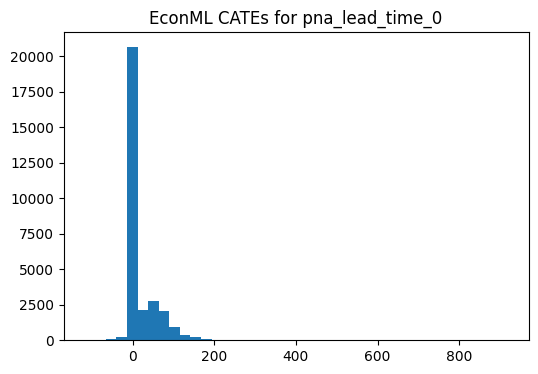


EconML CATE summary for pna_lead_time_1to2: mean=9.7368, sd=37.3274


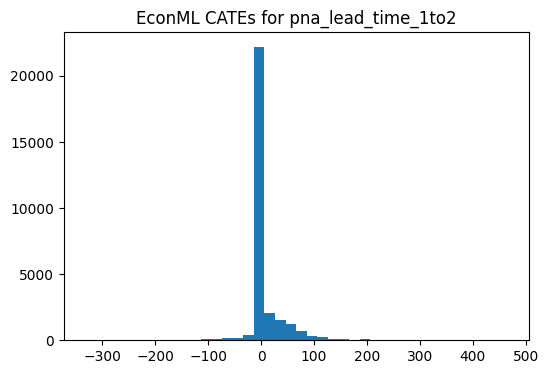


EconML CATE summary for pna_lead_time_3to7: mean=19.7695, sd=88.7628


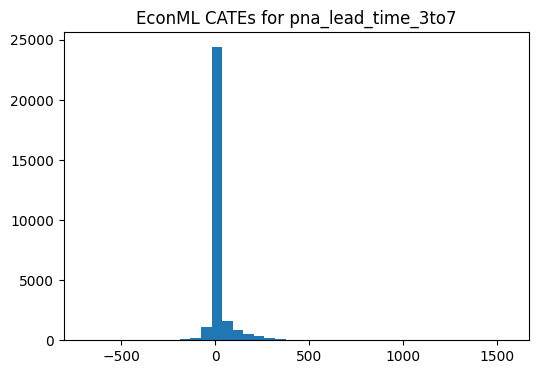


EconML CATE summary for pna_lead_time_8to14: mean=86.1131, sd=335.5216


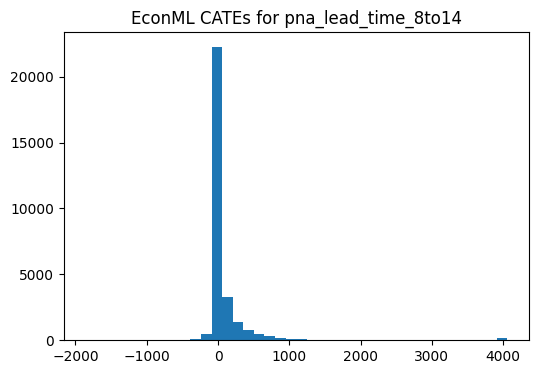


EconML CATE summary for pna_lead_time_15to30: mean=29.6640, sd=153.9011


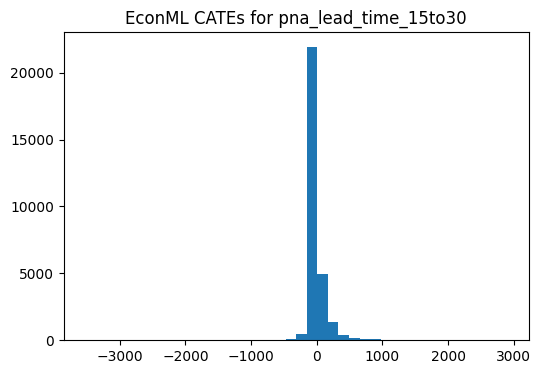


EconML CATE summary for pna_lead_time_31to59: mean=18.5598, sd=125.7982


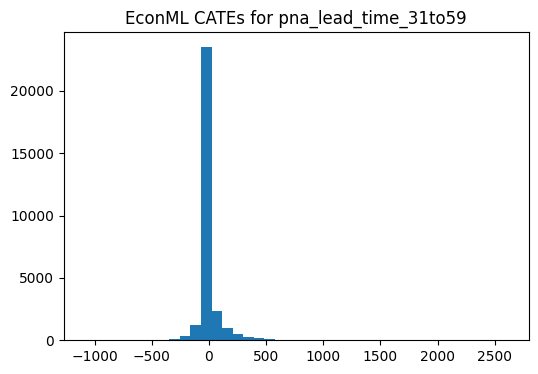


EconML CATE summary for pna_lead_time_60andAbove: mean=-28.8655, sd=95.8034


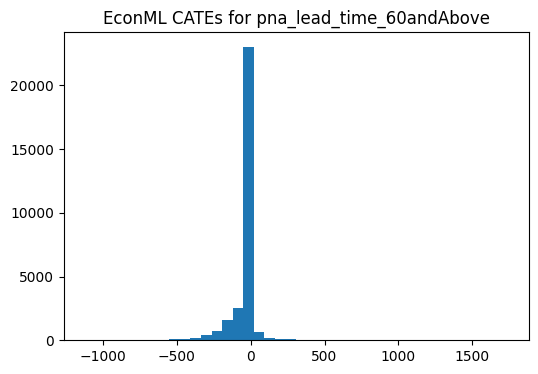

In [ ]:
# discount_analysis_pipeline.py
"""
Unified discount-effects analysis pipeline.

Assumptions:
- Your trained CatBoostRegressor object is available as `ctr` (pass it in).
- Target column name is "total_revenue".
- You provide lists: cat_cols (categorical), cont_cols (continuous; includes discount_cols), discount_cols (subset).
- The DataFrame passed may contain extra columns; they'll be dropped for modeling/prediction.
- If expected feature columns are missing, an informative error is raised.

Provides:
- prepare_model_df(...) : ensures correct columns
- permutation importance
- SHAP (explainer, shap_values) + plotting utilities
- average marginal effects (finite diff)
- scenario simulation (revenue + profit under margin assumption)
- econml CausalForestDML per discount column (CATEs)
- DoWhy backdoor identification + linear regression + simple refutation
- run_pipeline(...) and run_pipeline_and_plot(...) orchestration functions
"""

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV

import shap

# econml & dowhy (make sure installed in your env)
from econml.dml import CausalForestDML
from dowhy import CausalModel

# ---------- CONFIG ----------
TARGET_COL = "total_revenue"
DEFAULT_MARGIN = 0.30 # profit = margin * predicted revenue by default
discount_cols = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]
in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]
print(cat_cols)
stock_variables = in_stock + not_in_stock + stock_unavailable

# ---------- UTILITIES ----------
def prepare_model_df(df: pd.DataFrame, cat_cols, cont_cols, target_col=TARGET_COL):
    """
    Return df_model (subset) and features list.
    Drops any extra columns not used by model. Raises if any expected feature or target is missing.
    """
    cat_cols = list(cat_cols)
    cont_cols = list(cont_cols)
    features = cat_cols + cont_cols
    missing = [c for c in features if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected model feature columns: {missing}")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")
    df_model = df[features + [target_col]].copy()
    return df_model, features

# ---------- PERMUTATION IMPORTANCE ----------
def compute_permutation_importance(model, df_model, features, target_col=TARGET_COL, n_repeats=5):
    #print(features)
    X = df_model[features]
    y = df_model[target_col].values
    print("compute permutaion")
    res = permutation_importance(model, X, y, n_repeats=n_repeats, random_state=0,
                                 scoring="neg_mean_squared_error")
    print("compute permutaion - don")
    imp_df = pd.DataFrame({
        "feature": features,
        "imp_mean": res.importances_mean,
        "imp_std": res.importances_std
    }).sort_values("imp_mean", ascending=False).reset_index(drop=True)
    print(imp_df)
    return imp_df

# ---------- SHAP ----------
def shap_analysis(model, df_model, features, sample_size=2000, random_state=0):
    X = df_model[features]
    X_sample = X.sample(sample_size, random_state=random_state) if len(X) > sample_size else X.copy()
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    shap_abs_mean = pd.DataFrame(np.abs(shap_values), columns=X_sample.columns).mean().reset_index()
    shap_abs_mean.columns = ["feature", "mean_abs_shap"]
    shap_abs_mean = shap_abs_mean.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    return explainer, X_sample, shap_values, shap_abs_mean

# SHAP plotting helpers
def plot_shap_summary(explainer, X_sample, shap_values, max_display=20):
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=max_display, show=False)
    plt.title("Global SHAP feature importance")
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_values, X_sample, max_display=max_display, show=False)
    plt.title("SHAP beeswarm")
    plt.tight_layout(); plt.show()

def plot_shap_dependence_cols(shap_values, X_sample, cols):
    for col in cols:
        try:
            shap.dependence_plot(col, shap_values, X_sample, show=False)
            plt.title(f"SHAP dependence: {col}")
            plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"Could not plot dependence for {col}: {e}")

# ---------- AVERAGE MARGINAL EFFECT (finite diff) ----------
def average_marginal_effect(model, df_model, features_of_interest, delta=1.0):
    X = df_model[[c for c in df_model.columns if c != TARGET_COL]].copy()
    base_pred = model.predict(X)
    rows = []
    for feat in features_of_interest:
        if feat not in X.columns:
            raise ValueError(f"{feat} not in model features")
        X2 = X.copy()
        X2[feat] = X2[feat] + delta
        new_pred = model.predict(X2)
        diff = new_pred - base_pred
        rows.append({
            "feature": feat,
            "ame_per_unit": float(np.mean(diff)),
            "ame_std": float(np.std(diff)),
            "ame_median": float(np.median(diff))
        })
        gc.collect()
    return pd.DataFrame(rows).sort_values("ame_per_unit", ascending=False).reset_index(drop=True)

# ---------- SCENARIO SIMULATION ----------
def simulate_scenario(model, df_model, features, change_spec: dict, margin=DEFAULT_MARGIN):
    """
    change_spec: dict of {feature: delta} (delta can be positive or negative)
    Returns: revenue_delta, revenue_pct, profit_delta, per_row_delta (np.array)
    """
    X = df_model[features].copy()
    base_pred = model.predict(X)
    base_profit = base_pred * margin

    X_new = X.copy()
    for c, delta in change_spec.items():
        if c not in X_new.columns:
            raise ValueError(f"Feature '{c}' not present in model features.")
        X_new[c] = (X_new[c] + delta).clip(lower=0)

    new_pred = model.predict(X_new)
    new_profit = new_pred * margin

    return {
        "revenue_delta": float(new_pred.sum() - base_pred.sum()),
        "revenue_pct": float(new_pred.sum() / base_pred.sum() - 1) if base_pred.sum() != 0 else np.nan,
        "profit_delta": float(new_profit.sum() - base_profit.sum()),
        "per_row_delta": new_pred - base_pred
    }

def plot_scenarios(results_dict):
    """
    results_dict: {scenario_name: {"revenue_delta":..., "profit_delta":..., "revenue_pct":...}}
    """
    df = pd.DataFrame(results_dict).T
    if df.empty:
        print("No scenarios to plot.")
        return df
    df[["revenue_delta", "profit_delta"]].plot.bar(rot=45, figsize=(8,4))
    plt.ylabel("Absolute delta")
    plt.title("Scenario revenue & profit deltas")
    plt.tight_layout(); plt.show()
    print("\nScenario results (rounded):")
    print(df.round(2))
    return df

# ---------- ECONML: CausalForestDML ----------
def _prepare_controls_for_econml(df_model, cat_cols, cont_cols, treat_col, sample_frac=None, random_state=0):
    """
    Build X (controls), T (treatment), Y (outcome).
    One-hot encode categorical controls.
    """
    # features excluding treat
    features = [c for c in list(cat_cols) + list(cont_cols) if c != treat_col]
    df_controls = df_model[features].copy()

    # one-hot cat cols
    cat_present = [c for c in cat_cols if c in df_controls.columns]
    df_cat = pd.get_dummies(df_controls[cat_present].astype(str), drop_first=True) if cat_present else pd.DataFrame(index=df_controls.index)

    cont_present = [c for c in cont_cols if (c in df_controls.columns) and (c not in cat_cols)]
    df_cont = df_controls[cont_present].copy() if cont_present else pd.DataFrame(index=df_controls.index)

    X = pd.concat([df_cont.reset_index(drop=True), df_cat.reset_index(drop=True)], axis=1)
    T = df_model[treat_col].values.reshape(-1, 1)
    Y = df_model[TARGET_COL].values

    if sample_frac and 0 < sample_frac < 1:
        idx = df_model.sample(frac=sample_frac, random_state=random_state).index
        X = X.loc[idx].reset_index(drop=True)
        T = T[idx]
        Y = Y[idx]
    return X, T, Y

def econml_causal_forest(df_model, cat_cols, cont_cols, treat_col, sample_frac=0.4, random_state=0):
    """
    Fit CausalForestDML to estimate per-row CATEs of treat_col on TARGET_COL.
    Returns (cate_array, fitted_estimator).
    """
    X, T, Y = _prepare_controls_for_econml(df_model, cat_cols, cont_cols, treat_col, sample_frac=sample_frac, random_state=random_state)
    # learners
    model_y = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=random_state)
    model_t = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=random_state)
    est = CausalForestDML(model_y=model_y, model_t=model_t, discrete_treatment=False, random_state=random_state)
    est.fit(Y, T, X=X.values)
    cate = est.effect(X.values)
    return cate, est

# ---------- DoWhy backdoor linear ----------
def dowhy_backdoor_linear(df_model, treatment_col, common_causes):
    """
    Build DoWhy causal model and estimate via backdoor.linear_regression.
    Returns (identified_estimand, estimate, refute_result).
    """
    # Build model with selected common causes
    model = CausalModel(data=df_model, treatment=treatment_col, outcome=TARGET_COL, common_causes=common_causes)
    identified_estimand = model.identify_effect()
    estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
    # simple refutation: random_common_cause
    refute = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
    return identified_estimand, estimate, refute

# ---------- ORCHESTRATOR ----------
def run_pipeline(df, ctr, cat_cols, cont_cols, discount_cols,
                 shap_sample_size=2000,
                 run_econml=True, econml_sample_frac=0.4,
                 run_dowhy=True):
    """
    Run the full analysis and return a results dict.
    """
    # 1) prepare model df (drops extra cols; raises if missing)
    df_model, features = prepare_model_df(df, cat_cols, cont_cols, target_col=TARGET_COL)
    print("model prepared")
    results = {}
    results['features'] = features

    print("permutation importance")
    try:
        results['perm_imp'] = compute_permutation_importance(ctr, df_model, features)
    except Exception as e:
        results['perm_imp_error'] = str(e)

    print("SHAP")
    try:
        explainer, X_sample, shap_values, shap_summary = shap_analysis(ctr, df_model, features, sample_size=shap_sample_size)
        results['shap'] = {
            "explainer": explainer,
            "X_sample": X_sample,
            "shap_values": shap_values,
            "shap_summary_df": shap_summary
        }
    except Exception as e:
        results['shap_error'] = str(e)




    print("AME")
    try:
        results['ame'] = average_marginal_effect(ctr, df_model, discount_cols, delta=1.0)
    except Exception as e:
        results['ame_error'] = str(e)

    print("sceneraio errors")

    try:
        scenario_results = {}
        for d in discount_cols:
            scenario_results[f"+10_{d}"] = simulate_scenario(ctr, df_model, features, {d: 10})
        results['scenarios'] = scenario_results
    except Exception as e:
        results['scenarios_error'] = str(e)

    # 6) econml per discount col
    print("econml per dicount col")
    results['econml'] = {}
    if run_econml:
        for d in discount_cols:#variables considered
            try:
                cate, est = econml_causal_forest(df_model, cat_cols, discount_cols, d, sample_frac=econml_sample_frac)
                results['econml'][d] = {"cate": cate, "estimator": est}
            except Exception as e:
                results['econml'][d] = {"error": str(e)}

    print("dowhy")
    results['dowhy'] = {}
    if run_dowhy:
        try:
            top_feats = list(results.get('perm_imp', pd.DataFrame()).feature.head(20))
            if len(top_feats) == 0:
                top_feats = [f for f in features if f not in discount_cols][:20]
            for d in discount_cols:
                common_causes = [f for f in top_feats if f != d]
                ident, estimate, refute = dowhy_backdoor_linear(df_model, d, common_causes)
                results['dowhy'][d] = {"ident": ident, "estimate": estimate, "refute": refute}
        except Exception as e:
            results['dowhy_error'] = str(e)

    return results

# ---------- PLOTTING DRIVER ----------
def run_pipeline_and_plot(df, ctr, cat_cols, cont_cols, discount_cols,
                          shap_sample_size=2000,
                          run_econml=True, econml_sample_frac=0.4, run_dowhy=True):
    """
    Runs run_pipeline(...) and then produces SHAP plots, scenario bar charts,
    econml CATE histograms, and prints DoWhy outputs.
    """
    results = run_pipeline(df, ctr, cat_cols, cont_cols, discount_cols,
                           shap_sample_size=shap_sample_size,
                           run_econml=run_econml, econml_sample_frac=econml_sample_frac,
                           run_dowhy=run_dowhy)

    # SHAP plots
    if 'shap' in results:
        shap_info = results['shap']
        explainer = shap_info['explainer']
        X_sample = shap_info['X_sample']
        shap_values = shap_info['shap_values']
        shap_summary_df = shap_info['shap_summary_df']
        print("\nTop SHAP features:\n", shap_summary_df.head(20))
        plot_shap_summary(explainer, X_sample, shap_values, max_display=20)
        # dependence for discount cols (first up to 4)
        plot_shap_dependence_cols(shap_values, X_sample, discount_cols[:4])

    # Scenario plots
    if 'scenarios' in results:
        print("\nPlotting scenario results...")
        plot_scenarios(results['scenarios'])

    # econml CATE histograms
    if 'econml' in results:
        for d, info in results['econml'].items():
            if 'cate' in info:
                cate = info['cate']
                print(f"\nEconML CATE summary for {d}: mean={np.mean(cate):.4f}, sd={np.std(cate):.4f}")
                plt.figure(figsize=(6,4)); plt.hist(cate, bins=40); plt.title(f"EconML CATEs for {d}"); plt.show()
            else:
                print(f"\nEconML for {d} error:", info.get('error'))

    # DoWhy outputs
    if 'dowhy' in results:
        for d, info in results['dowhy'].items():
            if 'estimate' in info:
                print(f"\nDoWhy estimate for {d}:")
                try:
                    print(info['estimate'])
                    print("Refutation result:")
                    print(info['refute'])
                except Exception as e:
                    print("Could not print DoWhy output:", e)
            else:
                if isinstance(info, dict) and 'error' in info:
                    print(f"\nDoWhy error for {d}: {info['error']}")

    return results

discount_cols = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]



lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
cat_cols = ["industry","discount_combo_2sets","set0_category"]
#cat_cols = ["discount_combo_2sets","set0_category"]

cont_cols = discount_cols + in_stock + not_in_stock + stock_unavailable + stock_unavailable + lead_times+other_cont

#from discount_analysis_pipeline import run_pipeline_and_plot
#results_discount= run_pipeline_and_plot(full, regr, cat_cols, cont_cols, discount_cols)
results_lead_times= run_pipeline_and_plot(full, regr, cat_cols, cont_cols, lead_times)

#

In [ ]:
#from IPython.display import display
#display(results_discount)

In [ ]:
discounts = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

no_discount = ["pna_discount_percentage_0"]
#lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
#cat_cols = [['industry']+  ["discount_combo_2sets","set0_category"]][0]#discount_combo_2sets	set0_category
cat_cols = ["industry","discount_combo_2sets","set0_category"]
regressor_cols = ["total_revenue"]
label_cols = ["purchase"]
other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
continuous_cols = in_stock + not_in_stock+ stock_unavailable+ discounts +  no_discount +lead_times +other_cont

#'pna_average_discount_percentage', 'days_diff_transaction', 'days_diff_session', 'pna_lead_time_15to30
all_cols = cat_cols + continuous_cols + regressor_cols #+ label_cols
print(cat_cols)
print(discounts)
print(no_discount)
print(continuous_cols)
print(len(all_cols))
#print(all_cols)

['industry', 'discount_combo_2sets', 'set0_category']
['pna_discount_percentage_0', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99']
['pna_discount_percentage_0']
['pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_discount_percentage_0', 'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20', 'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40', 'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60', 'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80', 'pna_discount_percenta

In [ ]:
# Keep the first occurrence; drop later duplicates for any duplicated name
import numpy as np


full_ = full.copy()
name = "pna_availability_message_available_to_ship_on"  # <-- make sure this is the exact duplicate name
# (Optional) normalize whitespace—helps if there are invisible spaces
full_.columns = full_.columns.map(lambda c: c.strip() if isinstance(c, str) else c)

# If you might have a MultiIndex, check first
if isinstance(full_.columns, pd.MultiIndex):
    # Example: duplicate is in the last level of the MultiIndex
    positions = [i for i, tpl in enumerate(full_.columns) if tpl[-1] == name]
else:
    positions = np.where(full_.columns.to_numpy() == name)[0].tolist()

print("Positions for the name:", positions)
print("Count before:", (full_.columns == name).sum() if not isinstance(full_.columns, pd.MultiIndex) else "N/A (MultiIndex)")

# Drop exactly the second occurrence (change the index you want to drop)
if len(positions) >= 2:
    j = positions[1]  # drop the 2nd one; use positions[0] to drop the 1st, etc.
    keep_idx = [i for i in range(full_.shape[1]) if i != j]
    full_ = full_.iloc[:, keep_idx]
else:
    print(f"No duplicate found for: {name!r}. Nothing dropped.")

# Verify
if not isinstance(full_.columns, pd.MultiIndex):
    print("Count after:", (full_.columns == name).sum())
#print(full_.columns)



Positions for the name: [5]
Count before: 1
No duplicate found for: 'pna_availability_message_available_to_ship_on'. Nothing dropped.
Count after: 1


In [ ]:
import unicodedata
full_ = full.copy()
def norm(s):
    if isinstance(s, str):
        s = unicodedata.normalize("NFKC", s)  # unify Unicode
        s = s.replace("\u200b", "")           # remove zero-width space
        s = s.strip()                         # trim whitespace
    return s

normed_cols = pd.Index([norm(c) for c in full_.columns])
dupes_after_norm = normed_cols[normed_cols.duplicated(keep=False)]
print("Duplicated after normalization:", dupes_after_norm.tolist())


Duplicated after normalization: []


In [ ]:
import numpy as np
import pandas as pd

def _class_name(obj):
    try:
        return obj.__class__.__name__
    except Exception:
        return type(obj).__name__

def summarize_econml_output(results, quantiles=(.1, .25, .5, .75, .9)):
    econ = results.get('econml', {}) or {}
    rows = []
    for var, payload in econ.items():
        cate = np.asarray(payload.get('cate'))
        if cate.ndim > 1:
            cate = cate.ravel()
        mask = ~np.isnan(cate)
        if mask.any():
            qs = np.quantile(cate[mask], quantiles)
        else:
            qs = [np.nan] * len(quantiles)
        rows.append({
            'variable': var,
            'n': int(cate.size),
            'n_nan': int(np.isnan(cate).sum()),
            'mean': float(np.nanmean(cate)) if cate.size else np.nan,
            'std': float(np.nanstd(cate)) if cate.size else np.nan,
            'min': float(np.nanmin(cate)) if cate.size else np.nan,
            **{f"q{int(q*100)}": float(v) for q, v in zip(quantiles, qs)},
            'max': float(np.nanmax(cate)) if cate.size else np.nan,
            'estimator': _class_name(payload.get('estimator'))
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(by='mean', ascending=True, ignore_index=True)
    return df

# Example: `results` is your dictionary from the run
#summary_df = summarize_econml_output(results_discount)#results_lead_times
summary_df = summarize_econml_output(results_lead_times)
# Display compact, readable table
with pd.option_context('display.float_format', '{:,.3f}'.format,
                       'display.max_rows', 200,
                       'display.max_colwidth', None):
    display(summary_df)


,variable,n,n_nan,mean,std,min,q10,q25,q50,q75,q90,max,estimator
0,pna_lead_time_60andAbove,29820,0,-28.866,95.803,"-1,122.341",-127.300,-9.327,-0.030,0.171,1.791,"1,737.732",CausalForestDML
1,pna_lead_time_1to2,29820,0,9.737,37.327,-333.008,-1.091,-0.098,0.053,1.982,45.178,465.295,CausalForestDML
2,pna_lead_time_31to59,29820,0,18.560,125.798,"-1,086.116",-30.776,-1.807,0.111,3.010,73.805,"2,611.032",CausalForestDML
3,pna_lead_time_3to7,29820,0,19.769,88.763,-695.596,-4.163,-0.146,0.052,1.465,64.746,"1,555.031",CausalForestDML
4,pna_lead_time_0,29820,0,20.621,42.044,-117.207,-0.414,0.003,0.766,29.142,74.015,918.324,CausalForestDML
5,pna_lead_time_15to30,29820,0,29.664,153.901,"-3,533.345",-16.741,-0.626,0.152,5.921,124.589,"2,903.348",CausalForestDML
6,pna_lead_time_8to14,29820,0,86.113,335.522,"-1,868.930",-7.213,-0.300,0.995,39.393,254.874,"4,059.398",CausalForestDML


In [ ]:
def _class_name(obj):
    try:
        return obj.__class__.__name__
    except Exception:
        return type(obj).__name__

def summarize_econml_output(results, quantiles=(.1, .25, .5, .75, .9)):
    econ = results.get('econml', {}) or {}
    rows = []
    for var, payload in econ.items():
        cate = np.asarray(payload.get('cate'))
        if cate.ndim > 1:
            cate = cate.ravel()
        mask = ~np.isnan(cate)
        if mask.any():
            qs = np.quantile(cate[mask], quantiles)
        else:
            qs = [np.nan] * len(quantiles)
        rows.append({
            'variable': var,
            'n': int(cate.size),
            'n_nan': int(np.isnan(cate).sum()),
            'mean': float(np.nanmean(cate)) if cate.size else np.nan,
            'std': float(np.nanstd(cate)) if cate.size else np.nan,
            'min': float(np.nanmin(cate)) if cate.size else np.nan,
            **{f"q{int(q*100)}": float(v) for q, v in zip(quantiles, qs)},
            'max': float(np.nanmax(cate)) if cate.size else np.nan,
            'estimator': _class_name(payload.get('estimator'))
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(by='mean', ascending=True, ignore_index=True)
    return df

# Example: `results` is your dictionary from the run
#summary_df = summarize_econml_output(results_stock)

# Display compact, readable table
with pd.option_context('display.float_format', '{:,.3f}'.format,
                       'display.max_rows', 200,
                       'display.max_colwidth', None):
    display(summary_df)

,variable,n,n_nan,mean,std,min,q10,q25,q50,q75,q90,max,estimator
0,pna_availability_message_check_cart_for_availability,54425,0,-3.586,265.993,"-3,941.217",-22.331,-0.116,0.000,0.007,4.766,"17,623.937",CausalForestDML
1,pna_availability_message_estimated_to_ship_on,54425,0,-0.438,17.121,-291.083,-3.024,-0.006,0.000,0.001,0.786,833.579,CausalForestDML
2,pna_availability_message_from,54425,0,4.449,79.518,"-1,029.346",-13.072,-0.150,0.000,0.196,23.223,"1,718.426",CausalForestDML
3,pna_availability_message_available_to_ship_on,54425,0,17.266,63.616,-471.934,-0.248,-0.026,0.001,0.530,53.577,917.053,CausalForestDML
4,pna_availability_message_in_stock,54425,0,29.012,69.036,-134.350,-0.028,0.000,0.020,5.548,116.698,"1,830.675",CausalForestDML


Top 10 variables by |mean CATE|: ['pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_60andAbove', 'pna_lead_time_0', 'pna_lead_time_3to7', 'pna_lead_time_31to59', 'pna_lead_time_1to2']


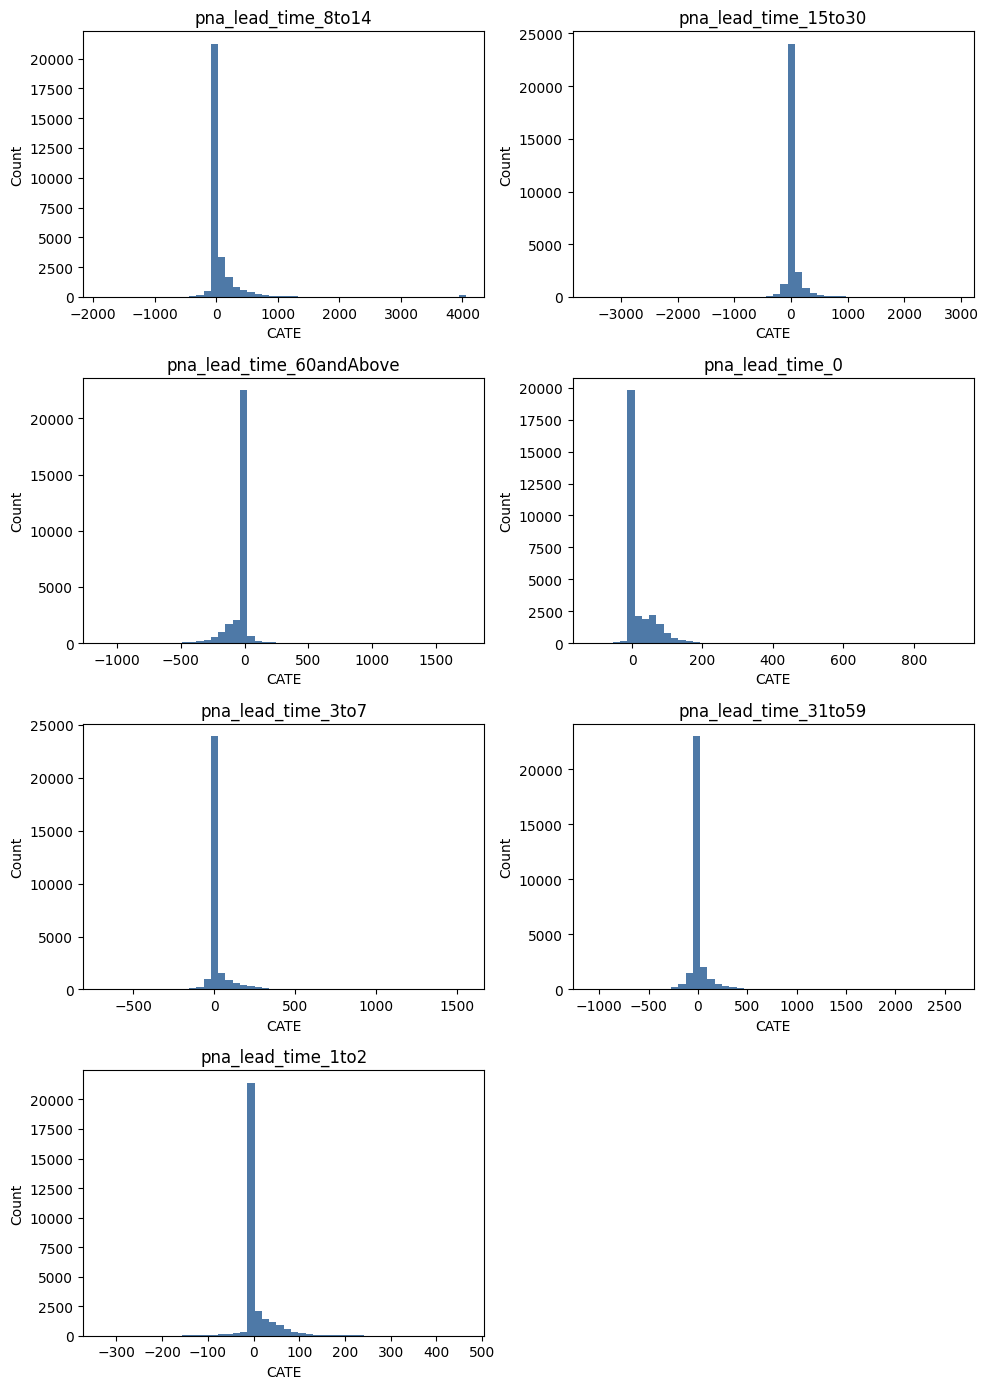

In [ ]:


# Show top-N by |mean|
topN = 10
top_vars = (summary_df.assign(abs_mean=lambda d: d['mean'].abs())
                        .sort_values('abs_mean', ascending=False)
                        .head(topN)['variable']
                        .tolist())

print(f"Top {topN} variables by |mean CATE|:", top_vars)

# Plot histograms for the top variables
#econ = results_discount.get('econml', {}) or {}results_lead_times
econ = results_lead_times.get('econml', {}) or {}
ncols = 2
nrows = int(np.ceil(len(top_vars)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5*nrows))
axes = np.atleast_1d(axes).ravel()

for ax, var in zip(axes, top_vars):
    cate = np.asarray(econ[var]['cate']).ravel()
    ax.hist(cate[~np.isnan(cate)], bins=50, color='#4e79a7')
    ax.set_title(var)
    ax.set_xlabel('CATE')
    ax.set_ylabel('Count')

for ax in axes[len(top_vars):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


Top 10 variables by |mean CATE|: ['pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_60andAbove', 'pna_lead_time_0', 'pna_lead_time_3to7', 'pna_lead_time_31to59', 'pna_lead_time_1to2']


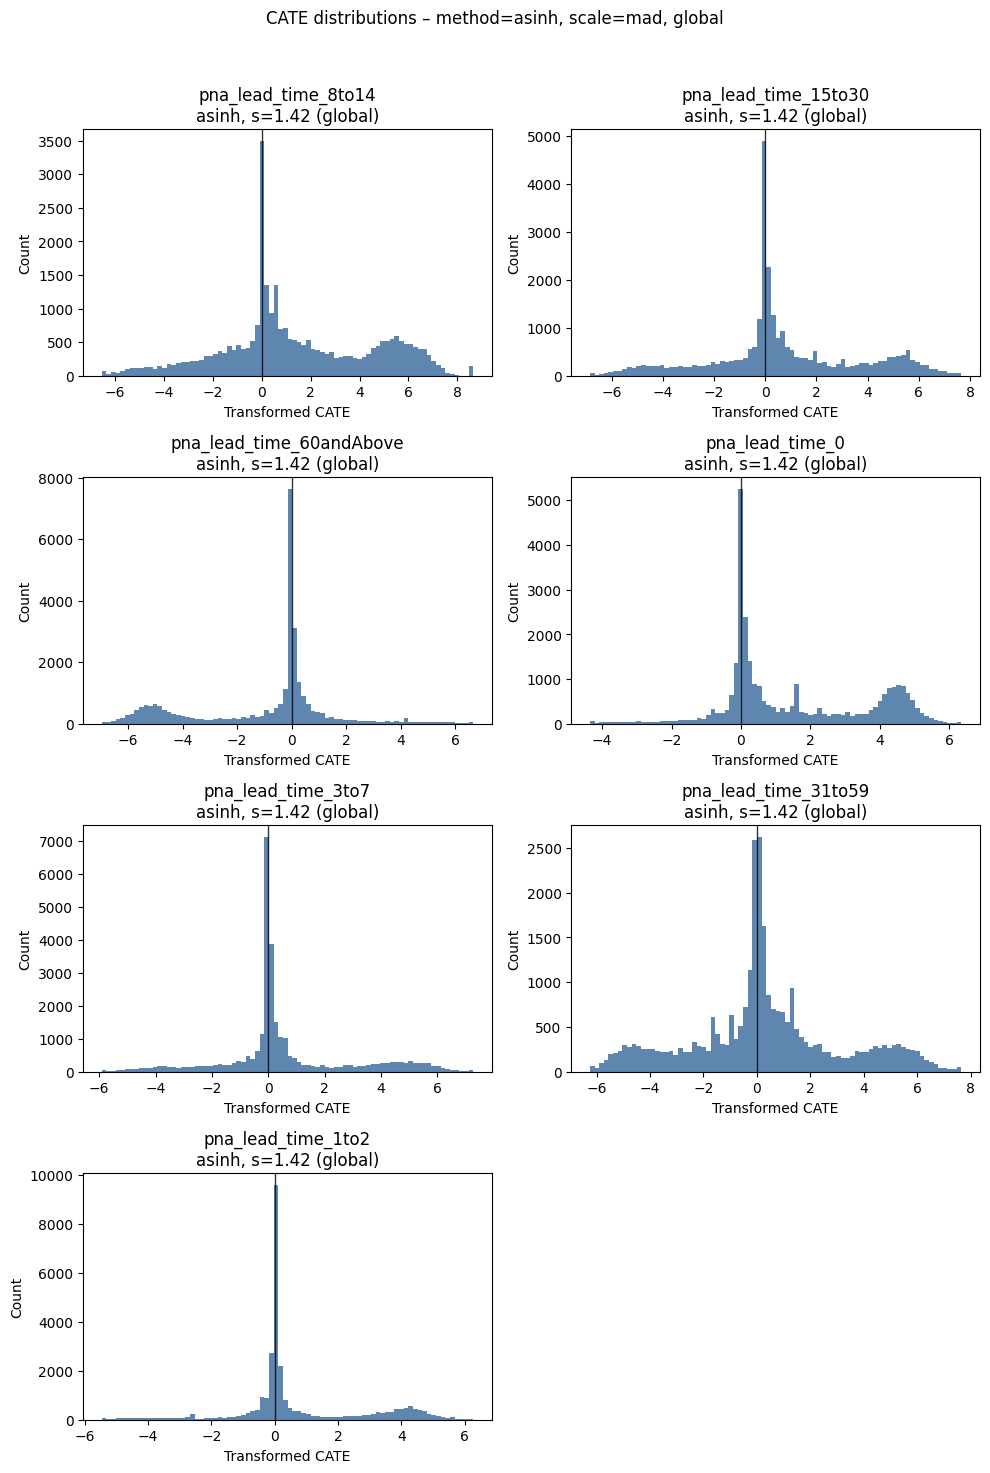

In [ ]:
# --- Utilities ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

method = 'asinh'
scale = 'mad'
use_global_scale = True
clip_pct = 0.1


method = 'symlog'
symlog_linthresh = 10  # widen/narrow the linear window around 0

method = 'yeojohnson'
use_global_scale = False  # not used for yeojohnson anyway


def mad(x):
    """Median Absolute Deviation (robust scale)."""
    x = np.asarray(x)
    med = np.nanmedian(x)
    m = np.nanmedian(np.abs(x - med))
    return m if m not in (None, 0) else 1.0

def transform_array(x, method='asinh', scale='mad', global_scale=None, symlog_linthresh=10):
    """
    Apply a transform to handle heavy tails while keeping sign & zero visible.

    method: 'none' | 'symlog' | 'signed_log1p' | 'asinh' | 'yeojohnson'
    scale:  'mad' | 'iqr' | float (only for signed_log1p/asinh)
    global_scale: None or float; if provided, overrides computed scale.
    """
    x = np.asarray(x).ravel()
    mask = np.isfinite(x)
    out = x.copy()

    if method == 'none':
        return out, {}

    if method == 'symlog':
        # No data transform; axis scaling will be applied in the plot
        return out, {'symlog_linthresh': symlog_linthresh}

    # Determine scale parameter s for tails (only for signed_log1p / asinh)
    if method in ('signed_log1p', 'asinh'):
        if global_scale is not None:
            s = float(global_scale) if global_scale != 0 else 1.0
        else:
            if scale == 'mad':
                s = mad(x[mask])
            elif scale == 'iqr':
                q1, q3 = np.nanpercentile(x, [25, 75])
                s = (q3 - q1) / 2.0
                s = s if s not in (None, 0) else 1.0
            elif isinstance(scale, (int, float)):
                s = float(scale) if scale != 0 else 1.0
            else:
                s = 1.0

    if method == 'signed_log1p':
        out[mask] = np.sign(x[mask]) * np.log1p(np.abs(x[mask]) / s)
        return out, {'s': s}

    if method == 'asinh':
        out[mask] = np.arcsinh(x[mask] / s)
        return out, {'s': s}

    if method == 'yeojohnson':
        # Learns a power transform that tends to Gaussianize (handles negatives)
        pt = PowerTransformer(method='yeo-johnson', standardize=True)
        out[mask] = pt.fit_transform(x[mask].reshape(-1,1)).ravel()
        lam = getattr(pt, 'lambdas_', [None])[0]
        return out, {'lambda_': lam}

    return out, {}

# --- Your original "Top-N by |mean|" selection ---
topN = 10
top_vars = (summary_df.assign(abs_mean=lambda d: d['mean'].abs())
                        .sort_values('abs_mean', ascending=False)
                        .head(topN)['variable']
                        .tolist())

print(f"Top {topN} variables by |mean CATE|:", top_vars)

# --- Parameters for transforms ---
method = 'asinh'          # 'none' | 'symlog' | 'signed_log1p' | 'asinh' | 'yeojohnson'
scale = 'mad'             # 'mad' | 'iqr' | float   (used by 'signed_log1p'/'asinh')
use_global_scale = True   # Use one global scale across variables for comparability
clip_pct = 0.1            # None or (e.g.) 0.1 to clip tails at 0.1% on each side (visualization only)
bins = 80
ncols = 2
symlog_linthresh = 10     # Only used for method='symlog'

# --- Plot histograms for the top variables with transform ---results_lead_times
#econ = results_discount.get('econml', {}) or {}
econ = results_lead_times.get('econml', {}) or {}
# Compute an optional global scale across selected variables (for signed_log1p/asinh)
global_scale = None
if method in ('signed_log1p', 'asinh') and use_global_scale:
    pooled = np.concatenate([np.asarray(econ[v]['cate']).ravel() for v in top_vars])
    pooled = pooled[np.isfinite(pooled)]
    global_scale = mad(pooled) if scale == 'mad' else None
    # If you set scale='iqr', you could compute a pooled IQR here similarly.

nrows = int(np.ceil(len(top_vars)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.6*nrows))
axes = np.atleast_1d(axes).ravel()

for ax, var in zip(axes, top_vars):
    cate = np.asarray(econ[var]['cate']).ravel()
    x = cate.copy()

    # Optional clipping to tame extreme tails visually (does not change data persistently)
    if clip_pct is not None:
        lo, hi = np.nanpercentile(x, [clip_pct, 100-clip_pct])
        x = np.clip(x, lo, hi)

    # Transform
    x_t, info = transform_array(
        x,
        method=method,
        scale=scale,
        global_scale=global_scale,
        symlog_linthresh=symlog_linthresh
    )

    # Plot
    ax.hist(x_t[np.isfinite(x_t)], bins=bins, color='#4e79a7', alpha=0.9)
    ax.axvline(0, color='k', lw=1, alpha=0.8)

    # Apply symlog axis if chosen
    if method == 'symlog':
        ax.set_xscale('symlog', linthresh=symlog_linthresh, linscale=1.0)
        ax.set_xlabel(f"CATE (symlog, linthresh={symlog_linthresh})")
    else:
        ax.set_xlabel("Transformed CATE" if method != 'none' else "CATE")

    # Title with transform info
    subtitle = ""
    if method in ('signed_log1p', 'asinh'):
        s = info.get('s', None)
        if s is not None:
            subtitle = f"\n{method}, s={s:.3g}{' (global)' if use_global_scale else ''}"
    elif method == 'yeojohnson':
        lam = info.get('lambda_', None)
        subtitle = f"\nYeo-Johnson{'' if lam is None else f', λ={lam:.3g}'}"
    elif method == 'symlog':
        subtitle = "\nsymlog axis"

    ax.set_title(f"{var}{subtitle}")
    ax.set_ylabel("Count")

# Hide any unused axes
for ax in axes[len(top_vars):]:
    ax.axis('off')

fig.suptitle(f"CATE distributions – method={method}, scale={scale}, "
             f"{'global' if (method in ('signed_log1p','asinh') and use_global_scale) else 'per-variable'}",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()


In [ ]:
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)
#print(cat_cols[])
#cat_cols  =# cat_cols[0]
cat_cols = ["industry","discount_combo_2sets","set0_category"]
print(cat_cols)
# Prevent column width truncation
pd.set_option('display.max_colwidth', None)
full_[cat_cols[0]] = full_[cat_cols[0]].astype('category')
full_[cat_cols[1]] = full_[cat_cols[1]].astype('category')
full_[cat_cols[2]] = full_[cat_cols[2]].astype('category')

cat_cols = [["industry", "discount_combo_2sets", "set0_category"]]
# Optional: widen the display in Colab
from IPython.display import display
#display(cat_cols)
#display(full_["pna_lead_time_1to2"].iloc[0:20])
print(results_df.iloc[0:10])


['industry', 'discount_combo_2sets', 'set0_category']


,pna_lead_time_1to2
0,1
1,2
2,6
3,4
4,6
5,1
6,9
7,1
8,2
9,12


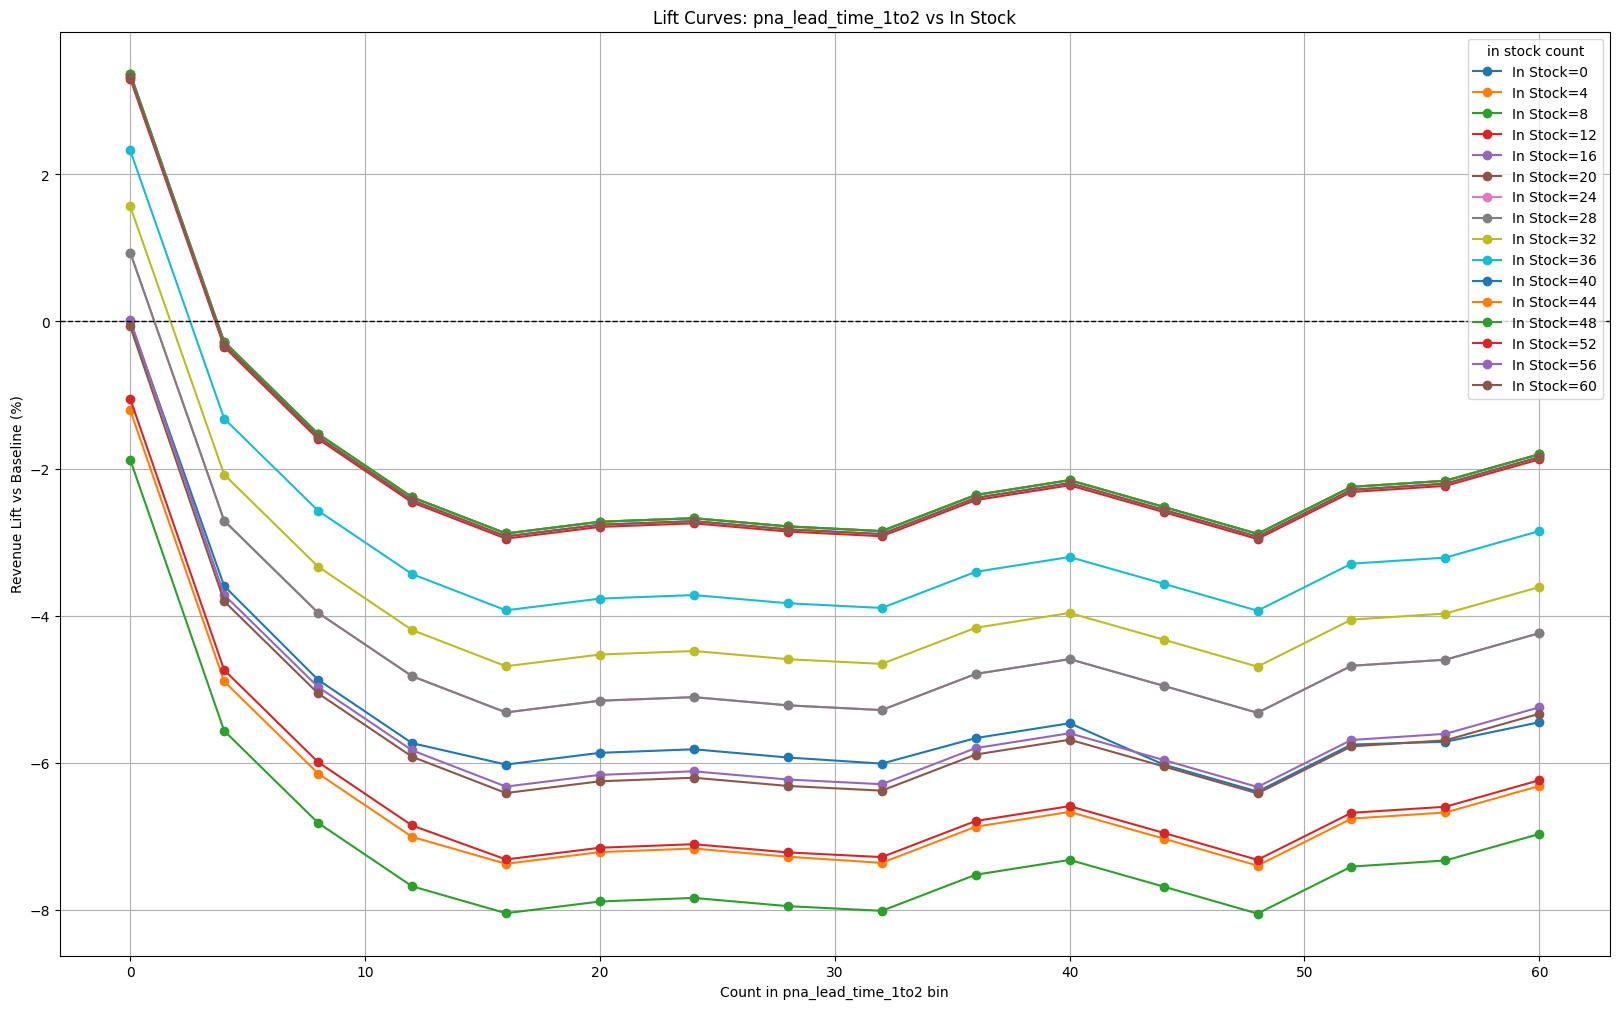

In [ ]:
# Assume your trained CatBoost model
# model = CatBoostRegressor().load_model("your_model.cbm")
"""
discount_cols = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]

not_in_stock = ["pna_availability_message_available_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14",
      "pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]

stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]
"""
model = regr.copy()
#disc_bin = "pna_discount_percentage_11to20"
#no_disc_col = "pna_discount_percentage_0"

lead_bin = "pna_lead_time_0"
no_lead_col = "pna_lead_time_60andAbove"


# Range of scenarios to test
scenarios = range(0, 61,4) # adjust as needed

results = []

for n_lead in scenarios:
    for n_no_lead in scenarios:
#for n_disc in scenarios:
#    for n_no_disc in scenarios:
        X_scenario = full_.copy()
        #X_scenario = X.copy()
        #X_scenario[disc_bin] = n_disc
        #X_scenario[no_disc_col] = n_no_disc

        X_scenario[lead_bin] = n_lead
        X_scenario[no_lead_col] = n_no_lead

        cat_cols = ["industry","discount_combo_2sets","set0_category"]
        pool = Pool(X_scenario, cat_features=cat_cols)
        y_pred = model.predict(pool)
        avg_revenue = np.mean(y_pred)



        results.append({
            "discount_count": n_lead,
            "no_discount_count": n_no_lead,
            "avg_revenue": avg_revenue
        })

        #results.append({
        #    "discount_count": n_disc,
        #    "no_discount_count": n_no_disc,
        #    "avg_revenue": avg_revenue
        #})

        gc.collect()
results_df = pd.DataFrame(results)

# --- Compute baseline ---
baseline = results_df.loc[
    (results_df["discount_count"] == 0) & (results_df["no_discount_count"] == 0),
    "avg_revenue"
].values[0]

results_df["lift_pct"] = (results_df["avg_revenue"] - baseline) / baseline * 100

# Pivot to plot lift curves
pivot_df = results_df.pivot(index="discount_count", columns="no_discount_count", values="lift_pct")

plt.figure(figsize=(20,12))
for no_disc in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[no_disc], marker="o", label=f"In Stock={no_disc}")

plt.xlabel("Count in pna_lead_time_1to2 bin")
plt.ylabel("Revenue Lift vs Baseline (%)")
plt.title("Lift Curves: pna_lead_time_1to2 vs In Stock")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="in stock count")
plt.grid(True)
plt.show()


In [ ]:
model = regr.copy()

# Assume your trained CatBoost model
# model = CatBoostRegressor().load_model("your_model.cbm")
"""
discount_cols = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]

not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]
"""

disc_bin = "pna_discount_percentage_21to30"
no_disc_col = "pna_availability_message_in_stock"

# Range of scenarios to test
scenarios = range(0, 41,4) # adjust as needed

results = []
cat_cols = cat_cols[0]
for n_disc in scenarios:
    for n_no_disc in scenarios:
        X_scenario = full_.copy()
        #X_scenario = X.copy()
        X_scenario[disc_bin] = n_disc
        X_scenario[no_disc_col] = n_no_disc


        cat_cols = ["industry","discount_combo_2sets","set0_category"]
        pool = Pool(X_scenario, cat_features=cat_cols)
        y_pred = model.predict(pool)
        avg_revenue = np.mean(y_pred)

        results.append({
            "discount_count": n_disc,
            "no_discount_count": n_no_disc,
            "avg_revenue": avg_revenue
        })
        gc.collect()
results_df = pd.DataFrame(results)

# --- Compute baseline ---
baseline = results_df.loc[
    (results_df["discount_count"] == 0) & (results_df["no_discount_count"] == 0),
    "avg_revenue"
].values[0]

results_df["lift_pct"] = (results_df["avg_revenue"] - baseline) / baseline * 100

# Pivot to plot lift curves
pivot_df = results_df.pivot(index="discount_count", columns="no_discount_count", values="lift_pct")

plt.figure(figsize=(20,12))
for no_disc in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[no_disc], marker="o", label=f"In Stock={no_disc}")

plt.xlabel("Count in discount_percentage_21to30 bin")
plt.ylabel("Revenue Lift vs Baseline (%)")
plt.title("Lift Curves: discount_percentage_21to30 vs In Stock")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="in stock count")
plt.grid(True)
plt.show()

In [ ]:
# Show all rows
pd.set_option('display.max_rows', None)
full_["industry"] = full_["industry"].astype("category")
# Show all columns
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)
print(full_.isna().sum())

# Optional: widen the display in Colab
from IPython.display import display
#display(full_.isna().sum())
mask = full_.apply(lambda col: col.astype(str).str.contains("Miscellaneous unsegm", na=False))
matches = full_[mask.any(axis=1)]
display(full_.columns)


industry                                                  0
total_transactions                                        0
total_sessions                                            0
order_history_page_views                                  0
products_pna_checked                                      0
pna_availability_message_available_to_ship_on             0
pna_availability_message_in_stock                         0
pna_availability_message_from                             0
pna_availability_message_check_cart_for_availability      0
pna_availability_message_estimated_to_ship_on             0
pna_average_discount_percentage                         438
pna_discount_percentage_0                                 0
pna_discount_percentage_1to10                             0
pna_discount_percentage_11to20                            0
pna_discount_percentage_21to30                            0
pna_discount_percentage_31to40                            0
pna_discount_percentage_41to50          

Index(['industry', 'total_transactions', 'total_sessions',
       'order_history_page_views', 'products_pna_checked',
       'pna_availability_message_available_to_ship_on',
       'pna_availability_message_in_stock', 'pna_availability_message_from',
       'pna_availability_message_check_cart_for_availability',
       'pna_availability_message_estimated_to_ship_on',
       'pna_average_discount_percentage', 'pna_discount_percentage_0',
       'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20',
       'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40',
       'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60',
       'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80',
       'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99',
       'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7',
       'pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_31to59',
       'pna_lead_time_60andAbove', 't

In [ ]:
print(full_.columns)
print(cat_cols)

Index(['industry', 'total_transactions', 'total_sessions',
       'order_history_page_views', 'products_pna_checked',
       'pna_availability_message_available_to_ship_on',
       'pna_availability_message_in_stock', 'pna_availability_message_from',
       'pna_availability_message_check_cart_for_availability',
       'pna_availability_message_estimated_to_ship_on',
       'pna_average_discount_percentage', 'pna_discount_percentage_0',
       'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20',
       'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40',
       'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60',
       'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80',
       'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99',
       'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7',
       'pna_lead_time_8to14', 'pna_lead_time_15to30', 'pna_lead_time_31to59',
       'pna_lead_time_60andAbove', 't

### ATE?

**ATE** = **Average Treatment Effect**  
It measures the *average difference in the outcome if everyone received the treatment vs. if no one did*.

Mathematically:

$$
\text{ATE} = \mathbb{E}[Y(1) - Y(0)]
$$

where:
- \( Y(1) \) = potential outcome if treated
- \( Y(0) \) = potential outcome if not treated



---

### CATE?

**CATE** = **Conditional Average Treatment Effect**  
It’s the treatment effect for a specific individual or subgroup given their features \(X\):

$$
\text{CATE}(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x]
$$

- **ATE** = average across everyone.
- **CATE** = effect conditional on characteristics (heterogeneous effects).


In [ ]:
print(availability_cols)
print(full.columns)


['pna_availability_message_in_stock', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'pna_availability_message_available_to_ship_on']
Index(['industry', 'total_transactions', 'total_sessions',
       'order_history_page_views', 'products_pna_checked',
       'pna_availability_message_available_to_ship_on',
       'pna_availability_message_in_stock', 'pna_availability_message_from',
       'pna_availability_message_check_cart_for_availability',
       'pna_availability_message_estimated_to_ship_on',
       'pna_average_discount_percentage', 'pna_discount_percentage_0',
       'pna_discount_percentage_1to10', 'pna_discount_percentage_11to20',
       'pna_discount_percentage_21to30', 'pna_discount_percentage_31to40',
       'pna_discount_percentage_41to50', 'pna_discount_percentage_51to60',
       'pna_discount_percentage_61to70', 'pna_discount_percentage_71to80',
       'pna_discount_percentage_81to90', 'pna_discount_percentage_90to99',
       'pna_lead

['pna_lead_time_15to30', 'industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_lead_time_1to2', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'total_revenue', 'pna_discount_percentage_81to90', 'pna_availability_message_in_stock', 'pna_discount_percentage_1to10', 'pna_lead_time_8to14', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'pna_lead_time_0', 'total_sessions', 'pna_lead_time_60andAbove', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_availability_message_available_to_ship_on', 'pna_discount_percentage_31to40', 'pna_lead_time_31to59', 'pna_discount_percentage_21to30', 'pna_lead_time_3to7']
[WARN] Dropping 1 unused co

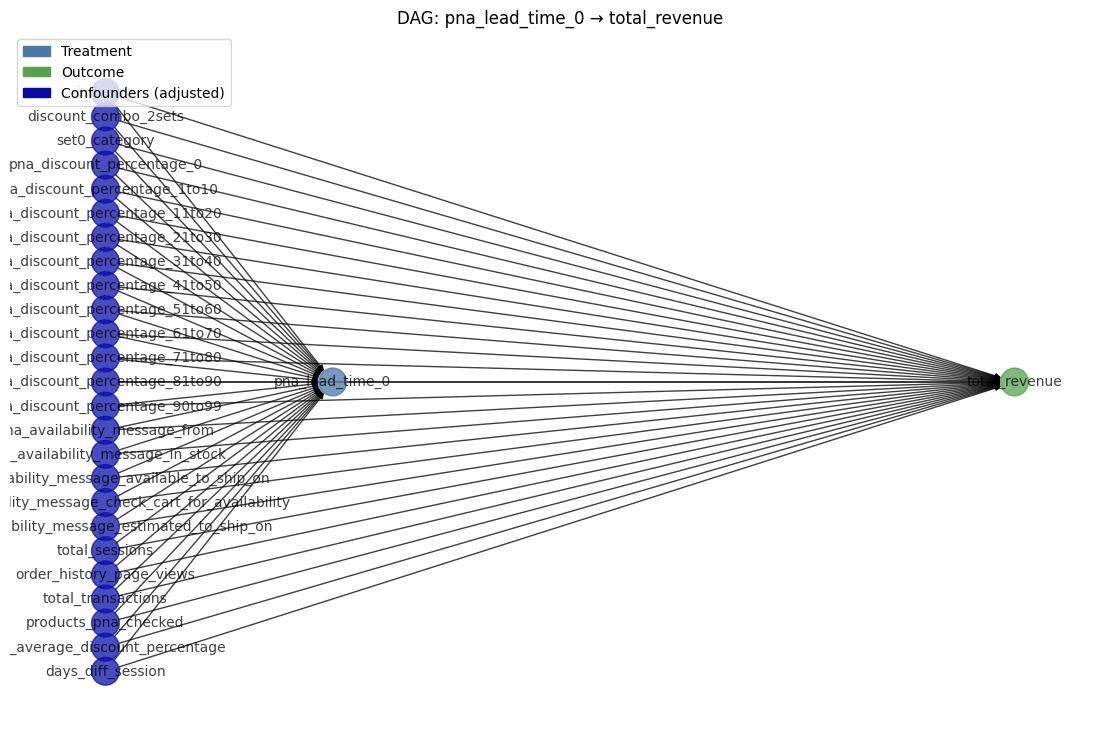

Backdoor set: {'backdoor1': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_availability_message_in_stock', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'total_sessions', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_availability_message_available_to_ship_on', 'pna_discount_percentage_21to30'], 'backdoor': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percent

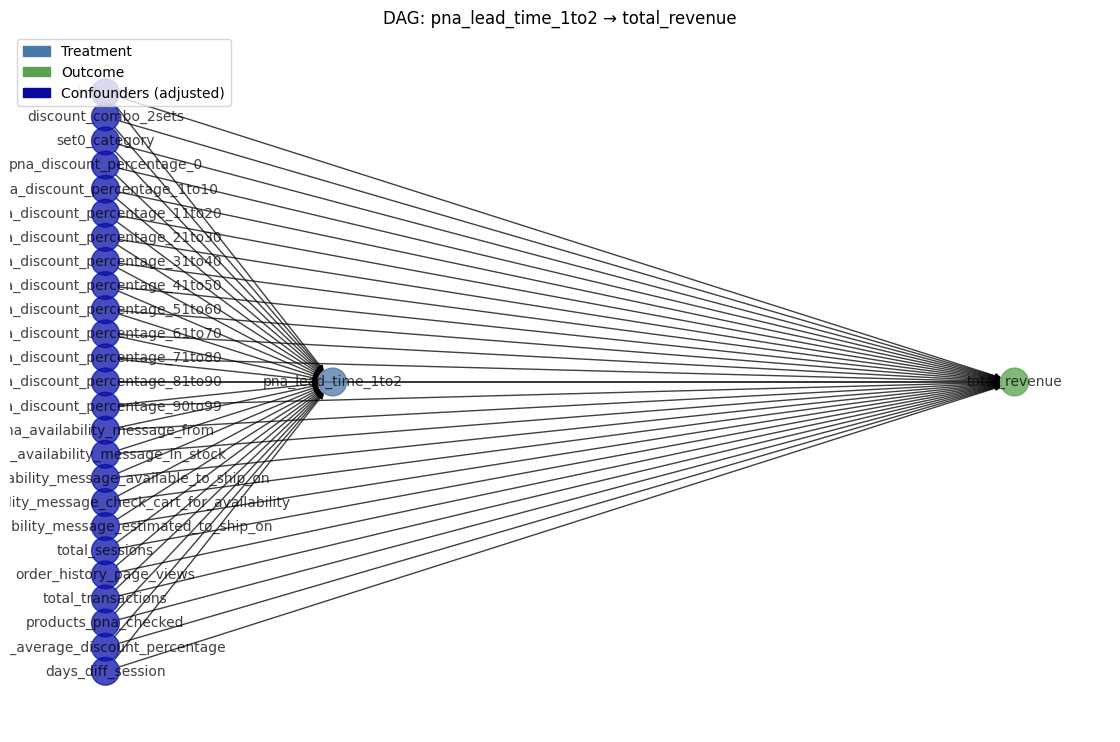

Backdoor set: {'backdoor1': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_availability_message_in_stock', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'total_sessions', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_availability_message_available_to_ship_on', 'pna_discount_percentage_21to30'], 'backdoor': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percent

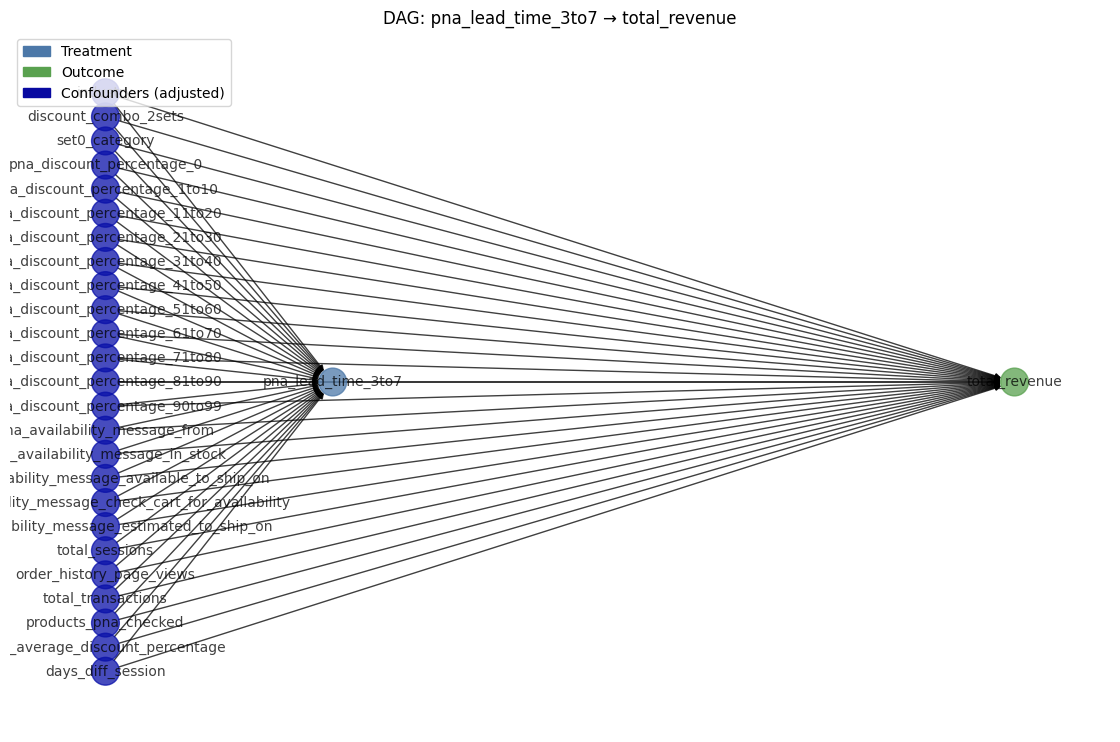

Backdoor set: {'backdoor1': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_availability_message_in_stock', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'total_sessions', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_availability_message_available_to_ship_on', 'pna_discount_percentage_21to30'], 'backdoor': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percent

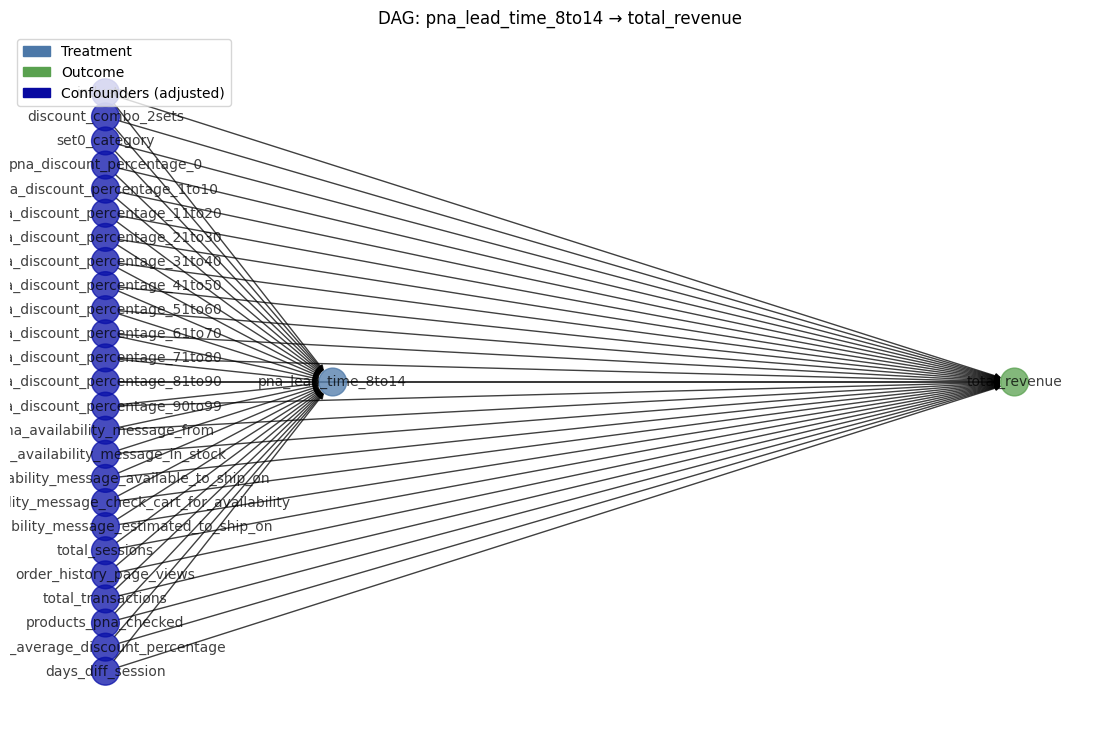

Backdoor set: {'backdoor1': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_availability_message_in_stock', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'total_sessions', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_availability_message_available_to_ship_on', 'pna_discount_percentage_21to30'], 'backdoor': ['industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percent

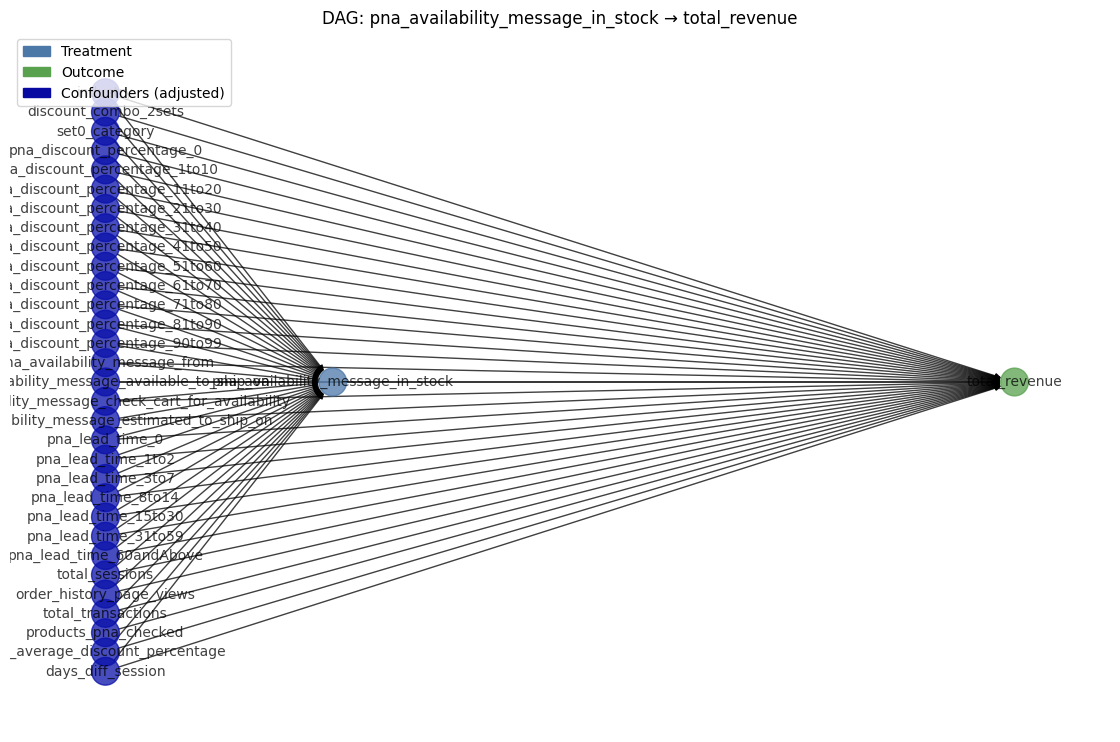

Backdoor set: {'backdoor1': ['pna_lead_time_15to30', 'industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_lead_time_1to2', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'pna_lead_time_0', 'total_sessions', 'pna_lead_time_60andAbove', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_lead_time_8to14', 'pna_availability_message_available_to_ship_on', 'pna_lead_time_31to59', 'pna_discount_percentage_21to30', 'pna_lead_time_3to7'], 'backdoor': ['pna_lead_time_15to30', 'industry', 'pn

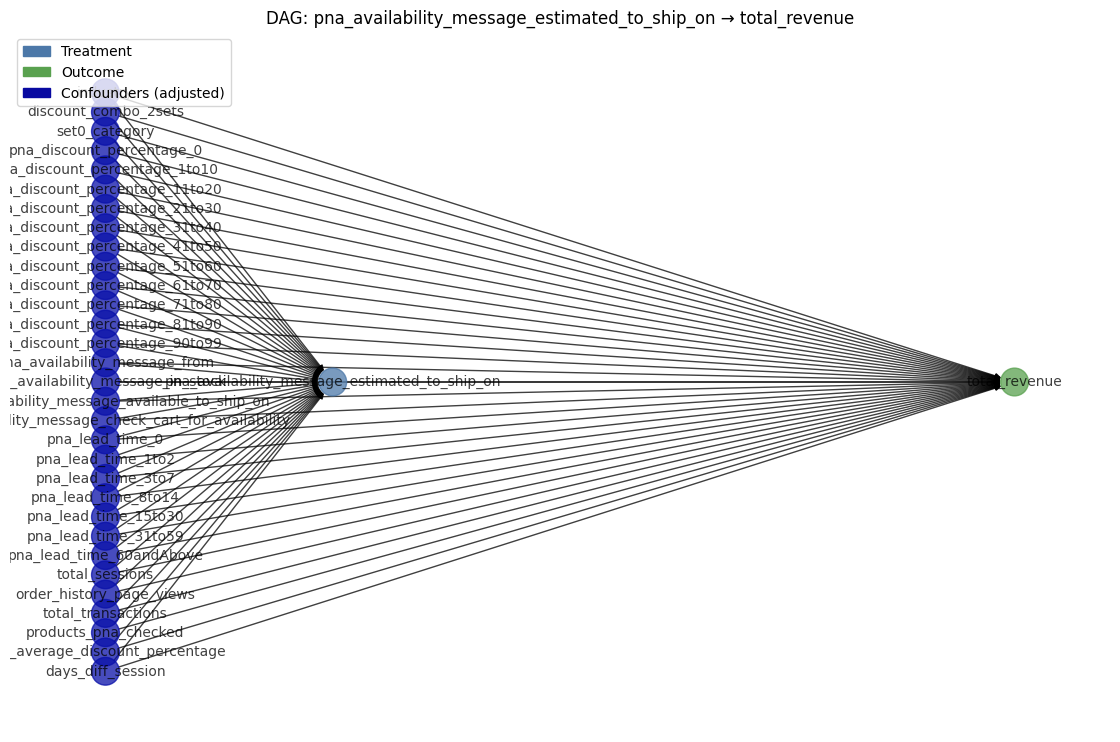

Backdoor set: {'backdoor1': ['pna_lead_time_15to30', 'industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_lead_time_1to2', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_availability_message_in_stock', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'pna_lead_time_0', 'total_sessions', 'pna_lead_time_60andAbove', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_lead_time_8to14', 'pna_availability_message_available_to_ship_on', 'pna_lead_time_31to59', 'pna_discount_percentage_21to30', 'pna_lead_time_3to7'], 'backdoor': ['pna_lead_time_15to30', 'industry', 'pna_discount_p

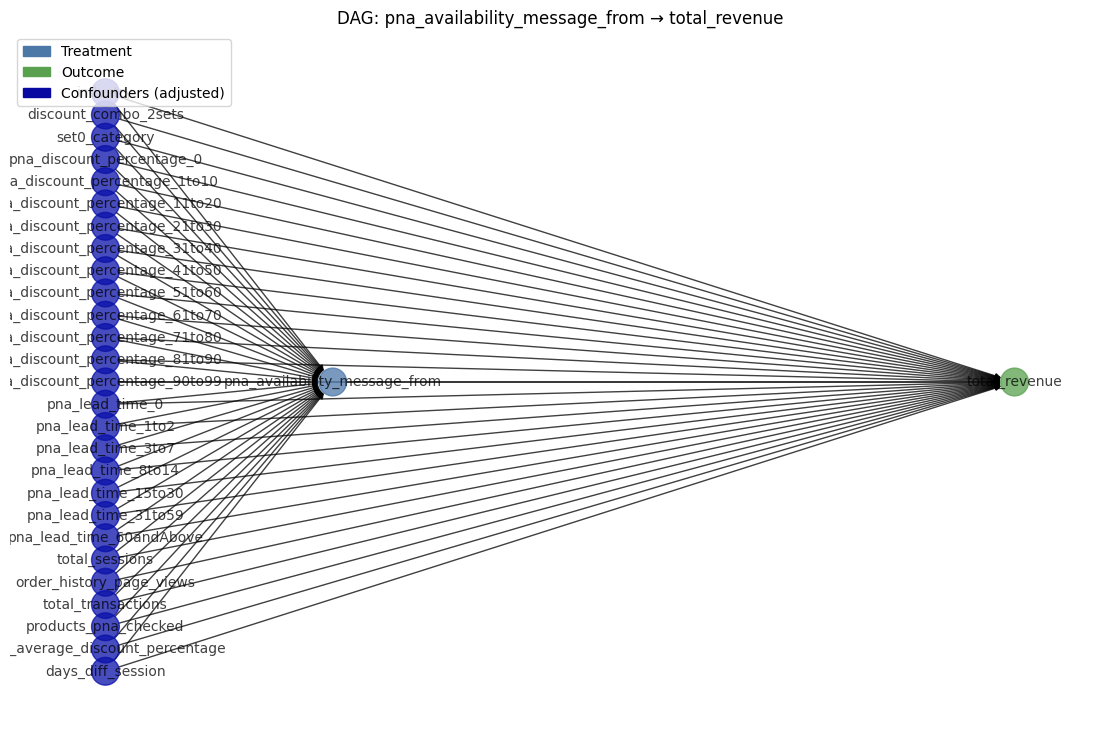

Backdoor set: {'backdoor1': ['pna_lead_time_15to30', 'industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_lead_time_1to2', 'pna_average_discount_percentage', 'pna_discount_percentage_0', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'total_transactions', 'pna_lead_time_0', 'pna_discount_percentage_21to30', 'total_sessions', 'pna_lead_time_60andAbove', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_lead_time_8to14', 'pna_lead_time_31to59', 'set0_category', 'pna_lead_time_3to7'], 'backdoor': ['pna_lead_time_15to30', 'industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_lead_time_1to2', 'pna_average_discount_percentage', 'pna_discount_percentage_0', 'order_history_page_views

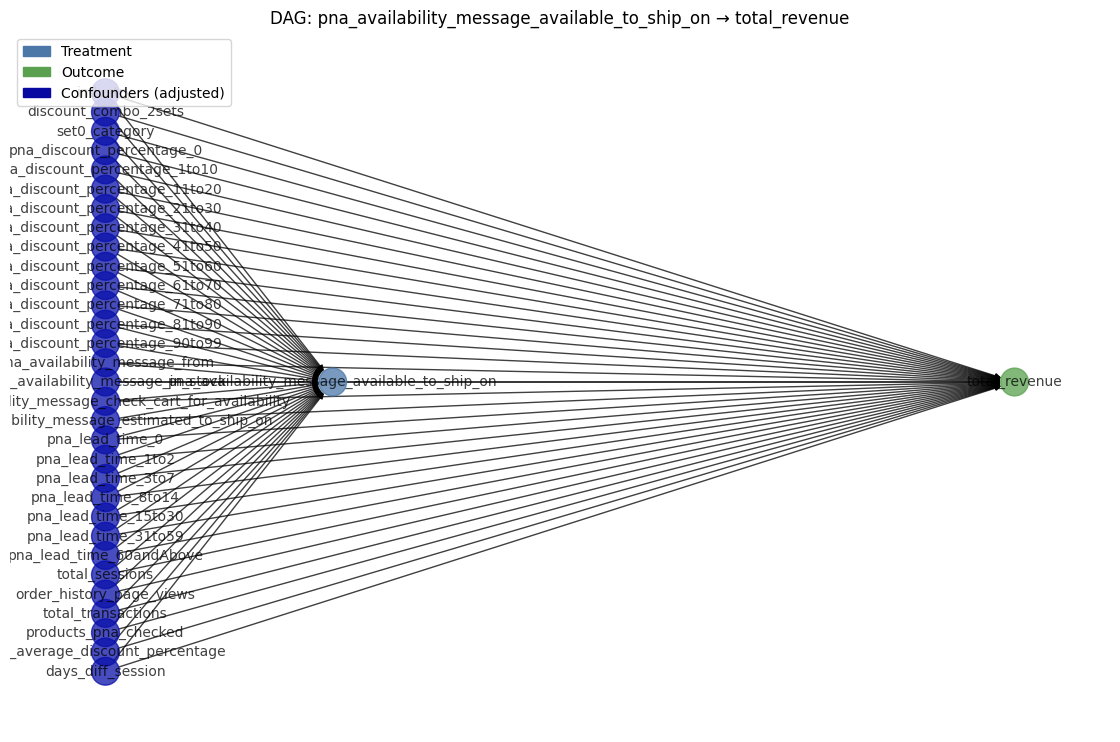

Backdoor set: {'backdoor1': ['pna_lead_time_15to30', 'industry', 'pna_discount_percentage_41to50', 'products_pna_checked', 'days_diff_session', 'pna_lead_time_1to2', 'pna_average_discount_percentage', 'set0_category', 'pna_discount_percentage_0', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_from', 'order_history_page_views', 'pna_discount_percentage_61to70', 'pna_discount_percentage_90to99', 'pna_discount_percentage_81to90', 'pna_availability_message_in_stock', 'pna_discount_percentage_1to10', 'pna_discount_percentage_51to60', 'pna_availability_message_check_cart_for_availability', 'total_transactions', 'pna_lead_time_0', 'total_sessions', 'pna_lead_time_60andAbove', 'discount_combo_2sets', 'pna_discount_percentage_11to20', 'pna_discount_percentage_71to80', 'pna_discount_percentage_31to40', 'pna_lead_time_8to14', 'pna_lead_time_31to59', 'pna_discount_percentage_21to30', 'pna_lead_time_3to7'], 'backdoor': ['pna_lead_time_15to30', 'industry', 'pna_discount_p

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import Pool
from econml.dml import CausalForestDML
from dowhy import CausalModel
from sklearn.impute import SimpleImputer
import gc
"""

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14",
      "pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
"""

#≈=======
#Two preprocess to debug.
#========
def preprocess_dataframe(full, all_cols, cat_cols, cont_cols, outcome_col):
    """
    - Keep only the columns used in training + outcome
    - Encode categoricals as integers
    - Impute NaNs in continuous cols
    - Warn if extra columns exist
    """

    keep_cols = list(set(all_cols +cat_cols + [outcome_col]))
    print(keep_cols)
    extra_cols = [c for c in full.columns if c not in keep_cols]

    if extra_cols:
        print(f"[WARN] Dropping {len(extra_cols)} unused columns: {extra_cols}")

    # Subset
    df = full[keep_cols].copy()

    # Encode categoricals
    for c in cat_cols:
        print(c)
        if df[c].dtype == "object" or str(df[c].dtype).startswith("category"):
            df[c] = pd.Categorical(df[c]).codes

    # Impute NaNs in continuous vars
    imp = SimpleImputer(strategy="median")
    df[cont_cols] = imp.fit_transform(df[cont_cols])

    # Impute outcome if needed
    if df[outcome_col].isna().any():
        df[outcome_col] = df[outcome_col].fillna(df[outcome_col].median())

    return df


#est = CausalForestDML(
#    n_estimators=48,   # or 52, 56, 60, ...
#    max_depth=5,
#    random_state=42,
#)


# ===================================================
# EconML causal analysis
# ===================================================
def run_econml_analysis(df, cols_of_interest, outcome_col, cat_cols, cont_cols):
    results = {}
    for col in cols_of_interest:
        print(f"\n[EconML] Running analysis for {col} → {outcome_col}")

        T = df[[col]].values
        Y = df[outcome_col].values
        # Drop treatment from X if included
        X = df.drop(columns=[col, outcome_col], errors="ignore").values

        est = CausalForestDML(
            n_estimators=48,
            max_depth=5,
            random_state=42,
        )
        print("subforest_size:", est.subforest_size)  # Usually 4 by default

        est.fit(Y, T, X=X)
        te_pred = est.effect(X)
        ate = te_pred.mean()

        results[col] = {"ate": ate, "effect_distribution": te_pred}
        print(f"[EconML] ATE for {col}: {ate:.4f}")
        gc.collect()
    return results

import warnings
import networkx as nx
from dowhy import CausalModel
"""
# --------------------------------------------------------------------
import matplotlib.pyplot as plt

def plot_dag___(G, title="Causal DAG"):
    plt.figure(figsize=(18, 12))
    pos = nx.spring_layout(G, seed=42)  # or nx.shell_layout(G)
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=700,
        node_color="#1010c6",
        arrowsize=8,
        font_size=8,
        #font_weight="i"
        #font_weight="bold",
        #font_family="DejaVu Sans"
    )


    plt.rcParams.update({"font.size": 10})
    plt.title(title)
    plt.show()
    gc.collect()
"""
# --------------------------------------------------------------------
import warnings
import networkx as nx
import matplotlib.pyplot as plt
from dowhy import CausalModel

def run_dowhy_analysis_improved(
    df,
    cols_of_interest,
    outcome_col,
    cat_cols=None,
    cont_cols=None,
    *,
    exclude_cols=None,                 # always exclude these from confounders
    post_treatment_cols=None,          # known post-treatment variables to exclude
    method_name="backdoor.linear_regression",
    proceed_when_unidentifiable=False, # fail fast by default
    exclude_alternate_treatment_bins=True,  # exclude other one-hot bins with same prefix
    run_refuters=False,                # run DoWhy refuters
    dropna="any",                      # "any" | "all" | None
    show_dag=True,                     # <<---- plot DAG inline (no Graphviz needed)
    dag_layout="layered",              # "layered" (clear, left→right) or "spring"
    verbose=True,
):
    """
    Estimate causal effects for multiple treatments using DoWhy,
    build an explicit DAG (networkx), and plot it with matplotlib (no Graphviz needed).
    """

    cat_cols = list(cat_cols or [])
    cont_cols = list(cont_cols or [])
    exclude_cols = set(exclude_cols or [])
    post_treatment_cols = set(post_treatment_cols or [])

    results = {}

    def _other_bins_with_same_prefix(all_cols, current):
        # Heuristic: same prefix up to the last underscore
        if "_" in current:
            prefix = current.rsplit("_", 1)[0] + "_"
            return {c for c in all_cols if c != current and c.startswith(prefix)}
        return set()

    def _layered_positions(confounders, treatment, outcome):
        """
        Place confounders on the left (x=0), treatment in the middle (x=0.5),
        and outcome on the right (x=1.0). Space confounders vertically.
        """
        n = len(confounders)
        pos = {}
        if n > 0:
            step = 1.0 / (n + 1)  # avoid nodes touching borders
            for i, c in enumerate(confounders, start=1):
                pos[c] = (0.0, 1.0 - i * step)
        else:
            # Keep layout valid even with zero confounders
            pos = {}
        pos[treatment] = (0.5, 0.5)
        pos[outcome] = (2.0, 0.5)
        return pos

    def _plot_dag(G, treatment, outcome, confounders, title, layout="layered"):
        # Colors by role
        node_colors = []
        for node in G.nodes():
            if node == treatment:
                node_colors.append("#4c78a8")  # blue
            elif node == outcome:
                node_colors.append("#59a14f")  # green
            else:
                node_colors.append("#0910a9")  # gray for confounders

        # Layout
        if layout == "layered":
            pos = _layered_positions(confounders, treatment, outcome)
            # Ensure all nodes have positions (in case of odd graph edits)
            for n in G.nodes():
                pos.setdefault(n, (1., 4.7))
        else:
            pos = nx.spring_layout(G, seed=42)

        # Draw
        plt.figure(figsize=(11, 7))
        nx.draw(
            G, pos,
            with_labels=True,
            node_size=400,
            node_color=node_colors,
            arrows=True,
            arrowsize=8,
            width=1.0,
            font_size=10,
            #font_weight="DejaVu",
            alpha=0.75,
            #node_size=700,
            #node_color="#121956",
            #arrowsize=8,
            #font_size=8,

        )
        plt.rcParams.update({"font.size": 10})
        # Legend
        import matplotlib.patches as mpatches
        patches = [
            mpatches.Patch(color="#4c78a8", label="Treatment"),
            mpatches.Patch(color="#59a14f", label="Outcome"),
            #mpatches.Patch(color="#a9a9a9", label="Confounders (adjusted)"),
            mpatches.Patch(color="#0809a1", label="Confounders (adjusted)"),
        ]
        plt.legend(handles=patches, loc="upper left", frameon=True)
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        gc.collect()
    for t in cols_of_interest:
        if verbose:
            print(f"\n[DoWhy] Running analysis for {t} → {outcome_col}")

        res = {
            "effect_estimate": None,
            "identified": False,
            "backdoor_set": [],
            "confounders_used": [],
            "n_rows": 0,
            "method": method_name,
            "warnings": [],
            "refuters": {},
            "error": None,
            "estimand": None,
        }

        try:
            # 1) Build candidate confounder set (pre-treatment only)
            cc_raw = cat_cols + cont_cols

            # Exclusions
            cc = [
                c for c in cc_raw
                if c not in {t, outcome_col}
                and c not in exclude_cols
                and c not in post_treatment_cols
            ]

            # Exclude other one-hot treatment bins
            if exclude_alternate_treatment_bins:
                other_bins = _other_bins_with_same_prefix(df.columns, t)
                cc = [c for c in cc if c not in other_bins]

            # Deduplicate, preserve order
            cc = list(dict.fromkeys(cc))

            # Debug overlap message
            if verbose:
                overlap = set(cc_raw) & {t, outcome_col}
                if overlap:
                    print(f"Removing from confounders due to overlap with treatment/outcome: {sorted(overlap)}")

            # 2) Subset data
            relevant_cols = [t, outcome_col] + cc
            sub_df = df[relevant_cols].copy()

            if dropna in ("any", "all"):
                before = len(sub_df)
                sub_df = sub_df.dropna(axis=0, how=dropna)
                after = len(sub_df)
                if verbose and before != after:
                    print(f"Dropped {before - after} rows due to NaNs in {relevant_cols}")

            res["n_rows"] = len(sub_df)
            if res["n_rows"] == 0:
                raise ValueError("No data rows after filtering/NaN handling.")

            # 3) DAG: confounders → treatment, confounders → outcome, treatment → outcome
            G = nx.DiGraph()
            G.add_nodes_from(relevant_cols)
            for c in cc:
                G.add_edge(c, t)
                G.add_edge(c, outcome_col)
            G.add_edge(t, outcome_col)

            # Ensure DAG
            if not nx.is_directed_acyclic_graph(G):
                raise ValueError("Constructed graph is not acyclic. Check confounders for unintended cycles.")

            # 4) Create model (pass both graph and explicit common_causes to avoid 'minimal set' search warnings)
            model = CausalModel(
                data=sub_df,
                treatment=t,
                outcome=outcome_col,
                graph=G,
                common_causes=cc
            )

            # 4a) Plot DAG inline (no Graphviz)
            if show_dag:
                _plot_dag(G, t, outcome_col, cc, title=f"DAG: {t} → {outcome_col}", layout=dag_layout)

            # 5) Identify
            identified = model.identify_effect(proceed_when_unidentifiable=proceed_when_unidentifiable)
            res["identified"] = getattr(identified, "is_identified", True)
            res["estimand"] = str(identified)

            if not res["identified"] and not proceed_when_unidentifiable:
                raise RuntimeError("No valid backdoor set identified (set proceed_when_unidentifiable=True to proceed).")

            if verbose:
                bd_vars = getattr(identified, "backdoor_variables", None)
                print("Backdoor set:", bd_vars)

            # 6) Estimate
            estimate = model.estimate_effect(identified, method_name=method_name)
            res["effect_estimate"] = float(getattr(estimate, "value", estimate))
            res["backdoor_set"] = list(getattr(identified, "backdoor_variables", cc) or [])
            res["confounders_used"] = cc

            print(f"[DoWhy] Effect for {t}: {res['effect_estimate']:.4f}")

            # 7) Optional refuters
            if run_refuters:
                try:
                    ref1 = model.refute_estimate(identified, estimate, method_name="random_common_cause")
                    res["refuters"]["random_common_cause"] = str(ref1)
                except Exception as e:
                    res["refuters"]["random_common_cause"] = f"Refuter failed: {e}"

                try:
                    ref2 = model.refute_estimate(identified, estimate, method_name="placebo_treatment_refuter")
                    res["refuters"]["placebo_treatment_refuter"] = str(ref2)
                except Exception as e:
                    res["refuters"]["placebo_treatment_refuter"] = f"Refuter failed: {e}"

                try:
                    ref3 = model.refute_estimate(identified, estimate, method_name="data_subset_refuter")
                    res["refuters"]["data_subset_refuter"] = str(ref3)
                except Exception as e:
                    res["refuters"]["data_subset_refuter"] = f"Refuter failed: {e}"

        except Exception as e:
            res["error"] = str(e)
            print(f"[DoWhy] Failed for {t}: {e}")

        results[t] = res

    return results

"""
def run_dowhy_analysis_improved_old(
    df,
    cols_of_interest,
    outcome_col,
    cat_cols=None,
    cont_cols=None,
    *,
    exclude_cols=None,                 # columns to always exclude from confounders
    post_treatment_cols=None,          # known post-treatment variables to exclude from confounders
    method_name="backdoor.linear_regression",
    proceed_when_unidentifiable=False, # fail fast by default
    exclude_alternate_treatment_bins=True,  # exclude other one-hot bins with same prefix
    run_refuters=False,                # run refuters to sanity check
    dropna="any",                      # how to drop NaNs in relevant columns: "any" | "all" | None
    verbose=True
):
    #Run DoWhy causal estimation for multiple treatment columns against one outcome,
    #with robust graph construction and confounder cleaning.




    cat_cols = list(cat_cols or [])
    cont_cols = list(cont_cols or [])
    exclude_cols = set(exclude_cols or [])
    post_treatment_cols = set(post_treatment_cols or [])

    results = {}

    def _other_bins_with_same_prefix(all_cols, current):
        #Find columns that look like alternative one-hot bins of the same concept
        # Heuristic: prefix up to the last underscore
        if "_" in current:
            prefix = current.rsplit("_", 1)[0] + "_"
            return {c for c in all_cols if c != current and c.startswith(prefix)}
        return set()

    for t in cols_of_interest:
        if verbose:
            print(f"\n[DoWhy] Running analysis for {t} → {outcome_col}")

        res = {
            "effect_estimate": None,
            "identified": False,
            "backdoor_set": [],
            "confounders_used": [],
            "n_rows": 0,
            "method": method_name,
            "warnings": [],
            "refuters": {},
            "error": None,
            "estimand": None,
        }

        try:
            # 1) Build candidate confounder set (pre-treatment only)
            cc_raw = cat_cols + cont_cols

            # Exclude treatment, outcome, explicit excludes, and known post-treatment columns
            cc = [
                c for c in cc_raw
                if c not in {t, outcome_col}
                and c not in exclude_cols
                and c not in post_treatment_cols
            ]

            # Optionally exclude other one-hot bins for the same concept
            if exclude_alternate_treatment_bins:
                other_bins = _other_bins_with_same_prefix(df.columns, t)
                cc = [c for c in cc if c not in other_bins]

            # Deduplicate while preserving order
            cc = list(dict.fromkeys(cc))

            if verbose:
                overlap = set(cc_raw) & {t, outcome_col}
                if overlap:
                    print(f" Removing from confounders because they overlap with treatment/outcome: {sorted(overlap)}")

            # 2) Subset data and drop NaNs if requested
            relevant_cols = [t, outcome_col] + cc
            sub_df = df[relevant_cols].copy()

            if dropna in ("any", "all"):
                before = len(sub_df)
                sub_df = sub_df.dropna(axis=0, how=dropna)
                after = len(sub_df)
                if verbose and before != after:
                    print(f"Dropped {before - after} rows due to NaNs in {relevant_cols}")

            res["n_rows"] = len(sub_df)

            if res["n_rows"] == 0:
                raise ValueError("No data rows after filtering/NaN handling.")

            # 3) Build explicit DAG using networkx (cc -> t, cc -> y, and t -> y)
            G = nx.DiGraph()
            G.add_nodes_from(relevant_cols)
            for c in cc:
                G.add_edge(c, t)
                G.add_edge(c, outcome_col)
            G.add_edge(t, outcome_col)

            # Sanity: ensure DAG
            if not nx.is_directed_acyclic_graph(G):
                raise ValueError("Constructed graph is not acyclic. Check confounder list for unintended cycles.")

            # 4) Create model
            model = CausalModel(
                data=sub_df,
                treatment=t,
                outcome=outcome_col,
                graph=G,
            )

            #save to disk if Graphvix

            #from IPython.display import Image, display

            #try:
            #    out_path = f"/content/dag_{t}.png"  # one file per treatment
            #    model.view_model(layout="dot", file_name=out_path, format="png")
            #    display(Image(filename=out_path))
            #except Exception as e:
           #     print("DAG visualization skipped (Graphviz not available?):", e)

            #if not
            plot_dag(G, title=f"DAG for {t} → {outcome_col}")





            # 5) Identify effect (fail fast by default)
            identified = model.identify_effect(proceed_when_unidentifiable=proceed_when_unidentifiable)
            res["identified"] = getattr(identified, "is_identified", True)
            res["estimand"] = str(identified)

            # If not identified and we allowed proceed_when_unidentifiable=True,
            # DoWhy will still let us estimate, but warn it's not guaranteed causal.
            if not res["identified"] and not proceed_when_unidentifiable:
                raise RuntimeError("No valid backdoor set identified (set proceed_when_unidentifiable=True to proceed).")

            if verbose:
                bd_vars = getattr(identified, "backdoor_variables", None)
                if bd_vars is not None:
                    print("Backdoor set:", bd_vars)

            # 6) Estimate effect
            estimate = model.estimate_effect(
                identified,
                method_name=method_name
            )
            res["effect_estimate"] = float(getattr(estimate, "value", estimate))
            res["backdoor_set"] = list(getattr(identified, "backdoor_variables", cc) or [])
            res["confounders_used"] = cc

            print(f"[DoWhy] Effect for {t}: {res['effect_estimate']:.4f}")

            # 7) Optional refuters
            if run_refuters:
                try:
                    ref1 = model.refute_estimate(identified, estimate, method_name="random_common_cause")
                    res["refuters"]["random_common_cause"] = str(ref1)
                except Exception as e:
                    res["refuters"]["random_common_cause"] = f"Refuter failed: {e}"

                try:
                    ref2 = model.refute_estimate(identified, estimate, method_name="placebo_treatment_refuter")
                    res["refuters"]["placebo_treatment_refuter"] = str(ref2)
                except Exception as e:
                    res["refuters"]["placebo_treatment_refuter"] = f"Refuter failed: {e}"

                try:
                    ref3 = model.refute_estimate(identified, estimate, method_name="data_subset_refuter")
                    res["refuters"]["data_subset_refuter"] = str(ref3)
                except Exception as e:
                    res["refuters"]["data_subset_refuter"] = f"Refuter failed: {e}"

        except Exception as e:
            msg = str(e)
            res["error"] = msg
            print(f"[DoWhy] Failed for {t}: {msg}")

        results[t] = res
        gc.collect()
    return results

"""



# ===================================================
# SHAP analysis
# ===================================================
def run_shap_analysis(model, df, cat_cols, cont_cols):
    print("\n[SHAP] Running SHAP analysis...")
    X = df[cat_cols + cont_cols]
    pool = Pool(X, cat_features=cat_cols)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(pool)

    plt.figure()
    shap.summary_plot(shap_values, X)
    plt.show()
    return shap_values

# ===================================================
# Summarize results
# ===================================================
def summarize_results(econml_results, dowhy_results):
    rows = []
    for col in econml_results.keys():
        ate = econml_results[col]["ate"]
        dowhy_est = dowhy_results.get(col, {}).get("effect_estimate", None)
        rows.append({
            "feature": col,
            "econml_ATE": ate,
            "dowhy_effect": dowhy_est
        })
    return pd.DataFrame(rows)

# ===================================================
# Full pipeline
# ===================================================
def discount_analysis_pipeline(
    full,
    ctr,
    discount_cols,
    availability_cols,
    cat_cols,
    cont_cols,
    all_cols,
    outcome_col="total_revenue"
):
    # Clean/preprocess data first
    df = preprocess_dataframe(full, all_cols, cat_cols, cont_cols, outcome_col)

    cols_of_interest = discount_cols[0:4] + availability_cols
    #dowhy_results = run_dowhy_analysis(df, cols_of_interest, outcome_col, cat_cols, cont_cols)
    dowhy_results =run_dowhy_analysis_improved(df, cols_of_interest, outcome_col, cat_cols, cont_cols)
    econml_results = run_econml_analysis(df, cols_of_interest, outcome_col, cat_cols, cont_cols)

    shap_values = run_shap_analysis(ctr, df, cat_cols, cont_cols)

    # Summary table
    summary = summarize_results(econml_results, dowhy_results)

    return {
        "econml": econml_results,
        "dowhy": dowhy_results,
        "shap": shap_values,
        "summary": summary
    }
availability_cols = [ "pna_availability_message_in_stock", "pna_availability_message_estimated_to_ship_on","pna_availability_message_from","pna_availability_message_available_to_ship_on"]

summary = discount_analysis_pipeline(full_,regr,discount_cols=lead_times,availability_cols=availability_cols,cat_cols=cat_cols,cont_cols=cont_cols,all_cols=all_cols)
# ===================================================
# Summarize results
# ===================================================
def summarize_results(econml_results, dowhy_results):
    rows = []
    for col in econml_results.keys():
        ate = econml_results[col]["ate"]
        dowhy_est = dowhy_results.get(col, {}).get("effect_estimate", None)
        rows.append({
            "feature": col,
            "econml_ATE": ate,
            "dowhy_effect": dowhy_est
        })
    return pd.DataFrame(rows)


In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import Pool
from econml.dml import CausalForestDML
from dowhy import CausalModel
discounts = ["pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

no_discount = ["pna_discount_percentage_0"]
#lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

in_stock = ["pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]

stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_estimated_to_ship_on"]

lead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"]
#cat_cols = [['industry']+  ["discount_combo_2sets","set0_category"]][0]#discount_combo_2sets	set0_category
cat_cols = ["industry","discount_combo_2sets","set0_category"]
regressor_cols = ["total_revenue"]
label_cols = ["purchase"]
other_cont = ['total_sessions','order_history_page_views','total_transactions',"products_pna_checked","pna_average_discount_percentage","days_diff_session"]
continuous_cols = in_stock + not_in_stock+ stock_unavailable+ discounts +  no_discount +lead_times +other_cont
mdl =  regr.copy()

In [ ]:
import numpy as np
import pandas as pd
from itertools import product
#
#"pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
#  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]
#mean	std	min	q10	q25	q50	q75	q90	max	estimator


#+72.9	[-1,320 , 2,259]
discount_effects = {
    "pna_discount_percentage_0": {"mean_effect": 9.90, "ci_low": -158.01, "ci_high": 177.01},
    "pna_discount_percentage_1to10": {"mean_effect": 71.02, "ci_low": -1346.0, "ci_high": 2847.025},
    #"pna_discount_percentage_10to11": {"mean_effect": 11.02, "ci_low": -1646, "ci_high": 1847.025},
    "pna_discount_percentage_21to30": {"mean_effect": 19.05, "ci_low":-1085.0, "ci_high": 947.08},
    "pna_discount_percentage_31to40": {"mean_effect": 41.02, "ci_low": -2789.707, "ci_high": 	25856.025},
    "pna_discount_percentage_41to50": {"mean_effect": 59.05, "ci_low": -56994.921, "ci_high": 	80165.521},
    "pna_discount_percentage_51to60": {"mean_effect": 91.02, "ci_low": -12794.866, "ci_high": 16876.580},
    "pna_discount_percentage_61to70": {"mean_effect": 185.05, "ci_low": -12975.161, "ci_high": 26159.514},
    "pna_discount_percentage_71to80": {"mean_effect": 214.02, "ci_low": -93073.159, "ci_high": 68564.226},
    "pna_discount_percentage_81to90": {"mean_effect": 225.05, "ci_low": -167454.110, "ci_high": 53455.525},
    "pna_discount_percentage_91to99": {"mean_effect": 706.05, "ci_low": -1112.271, "ci_high": 	18648.415},
}
effects_df = pd.DataFrame(discount_effects).T

# -----------------------
# Business inputs
# - observed_shares: current fraction of exposures per bin (sums to 1)
# - baseline_revenue_per_exposure: base $ revenue when exposure = 1 (before lift)
# - aov_by_bin: average order value associated with exposures in each bin (optional)
# - margin_by_bin: fraction profit margin (0-1) to convert revenue into profit
# - exposure_volume: total number of exposures you are allocating (for scaling)
# -----------------------
observed_shares = {
    #"discount_0": 0.20,
    #"discount_1_10": 0.40,
    #"discount_11_20": 0.20,
    #"discount_21_30": 0.15,
    #"discount_31_40": 0.05,
    "pna_discount_percentage_0":0.45,
    "pna_discount_percentage_1to10": 0.15,
    "pna_discount_percentage_21to30": 0.2,
    "pna_discount_percentage_31to40": 0.1,#80
    "pna_discount_percentage_41to50": 0.08,#88
    "pna_discount_percentage_51to60": 0.06,#94
    "pna_discount_percentage_61to70": 0.02,#96
    "pna_discount_percentage_71to80": 0.02,#
    "pna_discount_percentage_81to90": 0.01,#
    "pna_discount_percentage_91to99": 0.01,#
}
# baseline revenue per exposure (dollars). If you have AOV per bin, put that instead.
baseline_revenue_per_exposure = 20.0

# optional: different AOV or baseline revenue per bin (if available)
aov_by_bin = {
    "pna_discount_percentage_0":9.45,
    "pna_discount_percentage_1to10": 72.15,
    "pna_discount_percentage_21to30": 18.2,
    "pna_discount_percentage_31to40": 43.1,#80
    "pna_discount_percentage_41to50": 59.08,#88
    "pna_discount_percentage_51to60": 91.06,#94
    "pna_discount_percentage_61to70": 188.02,#96
    "pna_discount_percentage_71to80": 214.02,#
    "pna_discount_percentage_81to90": 224.01,#
    "pna_discount_percentage_91to99": 706.01,#
}
#aov_by_bin = {}

margin_by_bin = {
    "pna_discount_percentage_0":0.3,
    "pna_discount_percentage_1to10": 0.25,
    #"pna_discount_percentage_10to11": 0.3,
    "pna_discount_percentage_20to21": 0.3,
    "pna_discount_percentage_21to30": 0.41,
    "pna_discount_percentage_31to40": 0.44,
    "pna_discount_percentage_41to50": 0.51,
    "pna_discount_percentage_51to60": 0.68,
    "pna_discount_percentage_61to70": 0.74,
    "pna_discount_percentage_71to80": 0.73,
    "pna_discount_percentage_81to90": 0.93,
    "pna_discount_percentage_91to99": 1.21,
}

total_exposures = 1_000_000 # scale: total number of exposures you can reallocate

# -----------------------
# Convert relative effects to $ per exposure and $ profit per exposure
# -----------------------
def monetary_effects(effects_df, aov_by_bin, baseline_revenue_per_exposure=None, margin_by_bin=None):
    rows = []
    for b in effects_df.index:
        mean_rel = effects_df.loc[b, "mean_effect"]
        # pick a baseline revenue: prefer aov_by_bin if provided
        base_rev = aov_by_bin.get(b, baseline_revenue_per_exposure)
        dollar_lift = mean_rel * base_rev # $ increase in revenue per exposure
        margin = margin_by_bin.get(b, 0.30) if margin_by_bin is not None else 0.30
        dollar_profit = dollar_lift * margin
        ci_low = effects_df.loc[b, "ci_low"] * base_rev
        ci_high = effects_df.loc[b, "ci_high"] * base_rev
        rows.append({
            "bin": b,
            "mean_rel": mean_rel,
            "base_rev": base_rev,
            "dollar_lift": dollar_lift,
            "profit_per_exposure": dollar_profit,
            "ci_low_dollar": ci_low,
            "ci_high_dollar": ci_high
        })
    return pd.DataFrame(rows).set_index("bin")

mon_df = monetary_effects(effects_df, aov_by_bin, baseline_revenue_per_exposure, margin_by_bin)
print(mon_df)

# -----------------------
# Simulation: expected total profit given allocation (allocation sums to 1)
# and approximate risk (weighted CI width)
# -----------------------
def simulate_profit(allocation, mon_df, total_exposures):
    # allocation: dict {bin: share}, sums to 1
    shares = np.array([allocation[b] for b in mon_df.index])
    profit_per_exposure = mon_df["profit_per_exposure"].values
    # expected profit (total $)
    expected_profit = np.dot(shares, profit_per_exposure) * total_exposures
    # approximate risk proxy = weighted average half-ci (in $)
    half_ci = (mon_df["ci_high_dollar"].values - mon_df["ci_low_dollar"].values) / 2
    risk = np.dot(shares, half_ci) * total_exposures
    return expected_profit, risk

# -----------------------
# Utility/objective: maximize expected_profit - lambda*risk
# lambda = risk-aversion coefficient (higher => prefer safer allocations)
# -----------------------
def score_allocation(expected_profit, risk, lam=0.5):
    return expected_profit - lam * risk

# -----------------------
# Optimization (constrained grid search)
# - step controls grid granularity; smaller step => more computation
# - min_share/max_share: business constraints
# -----------------------
def optimize_allocation_grid(mon_df, step=0.05, lam=0.5, min_share=0.0, max_share=1.0, observed_shares=None):
    bins = list(mon_df.index)
    n = len(bins)
    best = {"score": -np.inf, "alloc": None, "expected_profit": None, "risk": None}
    grid = np.arange(0, 1+1e-9, step)

    # generate combinations that sum to 1 using recursion or product + filter.
    # Simple approach: n nested loops — viable for n <= ~6 and coarse step.
    def recurse(prefix, remaining, depth):
        if depth == n-1:
            # last bin gets remainder
            val = remaining
            if val < -1e-9:
                return
            alloc = prefix + [val]
            # apply min/max constraints
            if any(s < min_share-1e-9 or s > max_share+1e-9 for s in alloc):
                return
            allocation = {bins[i]: alloc[i] for i in range(n)}
            exp_profit, risk = simulate_profit(allocation, mon_df, total_exposures)
            sc = score_allocation(exp_profit, risk, lam=lam)
            nonlocal best
            if sc > best["score"]:
                best.update({"score": sc, "alloc": allocation, "expected_profit": exp_profit, "risk": risk})
            return
        else:
            for v in grid:
                if v < min_share - 1e-9 or v > max_share + 1e-9:
                    continue
                if v > remaining + 1e-9:
                    break
                recurse(prefix + [v], remaining - v, depth + 1)

    recurse([], 1.0, 0)
    return best

# -----------------------
# Example usage
# -----------------------
# Start with observed_shares as a candidate
best_current = {
    "alloc": observed_shares,
    "expected_profit": simulate_profit(observed_shares, mon_df, total_exposures)[0]
}
print("Current expected profit (observed shares):", best_current["expected_profit"])

best = optimize_allocation_grid(mon_df, step=0.1, lam=0.5, min_share=0.0, max_share=1.0)
print("Best score:", best["score"])
print("Best alloc:", best["alloc"])
print("Expected profit (best):", best["expected_profit"])
print("Risk (half-ci proxy):", best["risk"])

# Output markdown table for the best allocation
def allocation_to_markdown(allocation, mon_df):
    rows = []
    for bin_name, share in allocation.items():
        mean_rel = mon_df.loc[bin_name, "mean_rel"]
        dollar = mon_df.loc[bin_name, "dollar_lift"]
        profit = mon_df.loc[bin_name, "profit_per_exposure"]
        ci = f"[{mon_df.loc[bin_name,'ci_low_dollar']:.2f}, {mon_df.loc[bin_name,'ci_high_dollar']:.2f}]"
        rows.append(f"| {bin_name} | {share:.2f} | {mean_rel:.3f} | ${dollar:.2f} | ${profit:.2f} | {ci} |")
    header = (
        "| Discount Bin | Allocation Share | Mean Effect (rel) | $ lift/exposure | $ profit/exposure | CI ($) |\n"
        "|--------------|------------------|-------------------|------------------|-------------------|--------|\n"
    )
    return header + "\n".join(rows)

print(allocation_to_markdown(best["alloc"], mon_df))


                                mean_rel  base_rev  dollar_lift  \
bin                                                               
pna_discount_percentage_0           9.90      9.45      93.5550   
pna_discount_percentage_1to10      71.02     72.15    5124.0930   
pna_discount_percentage_21to30     19.05     18.20     346.7100   
pna_discount_percentage_31to40     41.02     43.10    1767.9620   
pna_discount_percentage_41to50     59.05     59.08    3488.6740   
pna_discount_percentage_51to60     91.02     91.06    8288.2812   
pna_discount_percentage_61to70    185.05    188.02   34793.1010   
pna_discount_percentage_71to80    214.02    214.02   45804.5604   
pna_discount_percentage_81to90    225.05    224.01   50413.4505   
pna_discount_percentage_91to99    706.05    706.01  498478.3605   

                                profit_per_exposure  ci_low_dollar  \
bin                                                                  
pna_discount_percentage_0                 28.066500  -1

In [ ]:
print(full_.dtypes)

industry                                                category
total_transactions                                         Int64
total_sessions                                             Int64
order_history_page_views                                   Int64
products_pna_checked                                       Int64
pna_availability_message_available_to_ship_on              Int64
pna_availability_message_in_stock                          Int64
pna_availability_message_from                              Int64
pna_availability_message_check_cart_for_availability       Int64
pna_availability_message_estimated_to_ship_on              Int64
pna_average_discount_percentage                          float64
pna_discount_percentage_0                                  Int64
pna_discount_percentage_1to10                              Int64
pna_discount_percentage_11to20                             Int64
pna_discount_percentage_21to30                             Int64
pna_discount_percentage_3

In [108]:
from IPython.display import Markdown, display

display(Markdown(r"""
# Causal Uplift & Multi‑Bin Reallocation — Equations

### Notation

- $X \in \mathbb{R}^p$: feature vector (no treatment columns in $X$).
- $T \in \{0,1,\dots,K-1\}$: discrete treatment / lead‑time bin. Baseline is $t_0 = 0$.
- $Y \in \mathbb{R}$: outcome (e.g., revenue).
- $\hat{\mu}_t(x) \approx \mathbb{E}[Y \mid X=x, T=t]$, $\hat{e}_t(x) \approx \Pr(T=t \mid X=x)$.
- $\widehat{\tau}(x; t, t_0)$: uplift of $t$ vs $t_0$.


### 2) Conditional Effect (Uplift)
$$
\tau(x; t, t_0)
=\mathbb{E}[Y \mid X=x, T=t]-\mathbb{E}[Y \mid X=x, T=t_0].
$$
$$
\begin{aligned}
\widehat{\tau}(x; t, t_0)
&= \big(\hat{\mu}_t(x) - \hat{\mu}_{t_0}(x)\big)
+ \frac{\mathbf{1}\{T=t\} - \hat{e}_t(x)}{\hat{e}_t(x)} \big(Y - \hat{\mu}_t(X)\big)
- \frac{\mathbf{1}\{T=t_0\} - \hat{e}_{t_0}(x)}{\hat{e}_{t_0}(x)} \big(Y - \hat{\mu}_{t_0}(X)\big).
\end{aligned}
$$

### 3) Average Uplift per Bin
$$
\text{AvgUplift}(t) = \frac{1}{n}\sum_{i=1}^n \widehat{\tau}(x_i; t, t_0).
$$

### 4) Expected Outcome (Revenue) per Bin
$$
\hat{\mu}_t = \frac{1}{n}\sum_{i=1}^n \hat{\mu}_t(x_i)
\quad\text{or}\quad
\hat{\mu}_t \approx \frac{1}{n}\sum_{i=1}^n \Big(\hat{\mu}_{t_0}(x_i)+\widehat{\tau}(x_i; t, t_0)\Big).
$$

### 5) Observed Allocation & Revenue
$$
\alpha_t = \frac{1}{n}\sum_{i=1}^n \mathbf{1}\{T_i=t\}, \quad \sum_t \alpha_t = 1,
\qquad
\text{Revenue}_{\text{observed}} = \sum_t \alpha_t \cdot \hat{\mu}_t.
$$

### 6) Multi‑Bin Reallocation
$$
\Delta_{f\to t}=\alpha_f \cdot \phi_{f\to t},\quad
\alpha_f'=\alpha_f-\sum_t \Delta_{f\to t},\quad
\alpha_t'=\alpha_t+\sum_f \Delta_{f\to t}.
$$
$$
\text{Revenue}_{\text{new}}=\sum_t \alpha_t' \cdot \hat{\mu}_t,
\qquad
\Delta \text{Revenue}= \text{Revenue}_{\text{new}}-\text{Revenue}_{\text{observed}}.
$$

### 7) Binary Outcome Variant
$$
\Delta P(t_1 \leftarrow t_0)
=
\mathbb{E}[\Pr(Y^{(b)}=1 \mid do(T=t_1), X)]
-
\mathbb{E}[\Pr(Y^{(b)}=1 \mid do(T=t_0), X)]
\approx
\frac{1}{n}\sum_{i=1}^{n} \widehat{\tau}(x_i; t_1, t_0).
$$
"""))



# Causal Uplift & Multi‑Bin Reallocation — Equations

### Notation

- $X \in \mathbb{R}^p$: feature vector (no treatment columns in $X$).
- $T \in \{0,1,\dots,K-1\}$: discrete treatment / lead‑time bin. Baseline is $t_0 = 0$.
- $Y \in \mathbb{R}$: outcome (e.g., revenue).
- $\hat{\mu}_t(x) \approx \mathbb{E}[Y \mid X=x, T=t]$, $\hat{e}_t(x) \approx \Pr(T=t \mid X=x)$.
- $\widehat{\tau}(x; t, t_0)$: uplift of $t$ vs $t_0$.


### 2) Conditional Effect (Uplift)
$$
\tau(x; t, t_0)
=\mathbb{E}[Y \mid X=x, T=t]-\mathbb{E}[Y \mid X=x, T=t_0].
$$
$$
\begin{aligned}
\widehat{\tau}(x; t, t_0)
&= \big(\hat{\mu}_t(x) - \hat{\mu}_{t_0}(x)\big)
+ \frac{\mathbf{1}\{T=t\} - \hat{e}_t(x)}{\hat{e}_t(x)} \big(Y - \hat{\mu}_t(X)\big)
- \frac{\mathbf{1}\{T=t_0\} - \hat{e}_{t_0}(x)}{\hat{e}_{t_0}(x)} \big(Y - \hat{\mu}_{t_0}(X)\big).
\end{aligned}
$$

### 3) Average Uplift per Bin
$$
\text{AvgUplift}(t) = \frac{1}{n}\sum_{i=1}^n \widehat{\tau}(x_i; t, t_0).
$$

### 4) Expected Outcome (Revenue) per Bin
$$
\hat{\mu}_t = \frac{1}{n}\sum_{i=1}^n \hat{\mu}_t(x_i)
\quad\text{or}\quad
\hat{\mu}_t \approx \frac{1}{n}\sum_{i=1}^n \Big(\hat{\mu}_{t_0}(x_i)+\widehat{\tau}(x_i; t, t_0)\Big).
$$

### 5) Observed Allocation & Revenue
$$
\alpha_t = \frac{1}{n}\sum_{i=1}^n \mathbf{1}\{T_i=t\}, \quad \sum_t \alpha_t = 1,
\qquad
\text{Revenue}_{\text{observed}} = \sum_t \alpha_t \cdot \hat{\mu}_t.
$$

### 6) Multi‑Bin Reallocation
$$
\Delta_{f\to t}=\alpha_f \cdot \phi_{f\to t},\quad
\alpha_f'=\alpha_f-\sum_t \Delta_{f\to t},\quad
\alpha_t'=\alpha_t+\sum_f \Delta_{f\to t}.
$$
$$
\text{Revenue}_{\text{new}}=\sum_t \alpha_t' \cdot \hat{\mu}_t,
\qquad
\Delta \text{Revenue}= \text{Revenue}_{\text{new}}-\text{Revenue}_{\text{observed}}.
$$

### 7) Binary Outcome Variant
$$
\Delta P(t_1 \leftarrow t_0)
=
\mathbb{E}[\Pr(Y^{(b)}=1 \mid do(T=t_1), X)]
-
\mathbb{E}[\Pr(Y^{(b)}=1 \mid do(T=t_0), X)]
\approx
\frac{1}{n}\sum_{i=1}^{n} \widehat{\tau}(x_i; t_1, t_0).
$$


In [104]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.base import clone
gc.collect()


# Which of the availability columns exist?
avail_cols = [c for c in full_.columns if c.startswith("pna_availability_message_")]
#print("All availability cols in df:", avail_cols)

#print("In cont_cols:", [c for c in cont_cols if c in avail_cols])
#print("In cat_cols:", [c for c in cat_cols if c in avail_cols])
#print("In lead_times:", [c for c in lead_times if c in avail_cols])

# After your num_cols filtering
num_cols = [c for c in cont_cols if c not in lead_times]
#print("In num_cols (post-filter):", [c for c in num_cols if c in avail_cols])

df_ = full_.copy()
df_["treatment_bin"] = collapse_discount_bins(df_, lead_times)
X = df_[cat_cols + num_cols]

dupes = X.columns[X.columns.duplicated()].unique().tolist()
print("Duplicate columns in X:", dupes)

missing = [c for c in avail_cols if c not in X.columns]
print("Availability columns missing from X:", missing)


num_cols = [c for c in cont_cols if c not in lead_times]



if "pna_availability_message_from" in full_.columns and \
   "pna_availability_message_from" not in (cat_cols + num_cols):
    num_cols.append("pna_availability_message_from")  # it's Int64, so treat as numeric

# Merge and drop duplicates while preserving order
feature_cols = list(dict.fromkeys(cat_cols + num_cols))

# Safety: ensure all exist in df_
missing_in_df = [c for c in feature_cols if c not in full_.columns]
if missing_in_df:
    raise KeyError(f"The following feature_cols are not in df_: {missing_in_df}")


def collapse_discount_bins(df, disc_cols):
    """Collapse multiple discount columns into a single categorical treatment variable."""
    treatment = df[disc_cols].idxmax(axis=1)
    return treatment.astype("category")

cat_cols_wo_treat = [c for c in cat_cols if c not in lead_times]
num_cols_wo_treat = [c for c in cont_cols if c not in lead_times]

feature_cols = list(dict.fromkeys(cat_cols_wo_treat + num_cols_wo_treat))

missing_in_df = [c for c in feature_cols if c not in full_.columns]
if missing_in_df:
    raise KeyError(f"Features not in df: {missing_in_df}")
if set(lead_times).intersection(feature_cols):
    raise ValueError("Treatment/lead_time columns leaked into X feature_cols.")

# ------------------------------------------------------------
# 1) Build X, T, Y and split
# ------------------------------------------------------------
df_ = full_.copy()
df_["treatment_bin"] = collapse_discount_bins(df_, lead_times)

X_df = df_[feature_cols]            # Raw DF (we'll transform to arrays below)
T_raw = df_["treatment_bin"]
Y_raw = df_["total_revenue"]

X_train_df, X_test_df, T_train_raw, T_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X_df, T_raw, Y_raw, test_size=0.2, random_state=42
)

# Clean Y and align indices
Y_train = pd.to_numeric(Y_train_raw, errors="coerce").astype(float)
mask_train = Y_train.notna()
X_train_df = X_train_df.loc[mask_train]
T_train_raw = T_train_raw.loc[mask_train]
Y_train = Y_train.loc[mask_train]

# Encode T deterministically: 0..k-1 (keep mapping for labels)
treat_categories = pd.Categorical(T_train_raw).categories

def encode_T(s: pd.Series) -> np.ndarray:
    return pd.Categorical(s, categories=treat_categories).codes

T_train = encode_T(T_train_raw)
T_test = encode_T(T_test_raw)

if (T_test < 0).any():
    raise ValueError("Unseen treatment category in test set; ensure consistent binning before split.")

import sklearn
skver = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
ohe_kwargs = {"handle_unknown": "ignore"}
ohe_kwargs["sparse_output" if skver >= (1, 2) else "sparse"] = False

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(**ohe_kwargs))
])
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols_wo_treat),
        ("num", numeric_transformer, num_cols_wo_treat),
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(X_train_df)
X_test  = preprocessor.transform(X_test_df)

print("X_train.shape:", X_train.shape, " X_test.shape:", X_test.shape)

outcome_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
propensity_model = LogisticRegressionCV(
    max_iter=200, multi_class="multinomial", solver="lbfgs", n_jobs=-1, Cs=10
)

dr_learner = DRLearner(
    model_regression=outcome_model,
    model_propensity=propensity_model,
    random_state=42
)

dr_learner.fit(Y_train.values, T_train, X=X_train)

# ------------------------------------------------------------
# 4) Uplift (const marginal effect) vs baseline (0)
# ------------------------------------------------------------
cme = dr_learner.const_marginal_effect(X_test)   # (n,) if binary else (n, k-1)
cme_2d = cme.reshape(-1, 1) if np.ndim(cme) == 1 else cme

baseline = 0
nonbase = list(range(1, len(treat_categories)))
colnames = [f"{treat_categories[j]} vs {treat_categories[baseline]}" for j in nonbase]

effect_df = pd.DataFrame(cme_2d, columns=colnames)
avg_uplift = effect_df.mean().sort_index()
print("\nAverage uplift (effect) vs baseline:")
print(avg_uplift)

# ------------------------------------------------------------
# 5) Expected Average Revenue per Discount Bin (levels, not uplift)
#    Handle cross-fitted lists of models transparently.
# ------------------------------------------------------------
def _avg_predict(model_or_collection, X_array):
    """
    Predicts E[Y|X,T] handling single estimator or a collection of fold estimators.
    Returns 1D array of predictions and averages across folds when needed.
    """
    # Single estimator
    if hasattr(model_or_collection, "predict"):
        return model_or_collection.predict(X_array)

    preds = []
    # List/Tuple of estimators (possibly nested)
    if isinstance(model_or_collection, (list, tuple)):
        for m in model_or_collection:
            if m is None:
                continue
            if hasattr(m, "predict"):
                preds.append(m.predict(X_array))
            elif isinstance(m, (list, tuple)):
                for mm in m:
                    if mm is not None and hasattr(mm, "predict"):
                        preds.append(mm.predict(X_array))
        if len(preds) == 0:
            raise ValueError("No valid estimators with predict() found in the list/tuple.")
        return np.mean(np.column_stack(preds), axis=1)

    # Dict of estimators
    if isinstance(model_or_collection, dict):
        for m in model_or_collection.values():
            if m is not None and hasattr(m, "predict"):
                preds.append(m.predict(X_array))
        if len(preds) == 0:
            raise ValueError("No valid estimators with predict() found in the dict.")
        return np.mean(np.column_stack(preds), axis=1)

    raise TypeError(f"Unsupported type for models_reg entry: {type(model_or_collection)}")

# Access per-class outcome models (name varies by econml version)
models_reg = (
    getattr(dr_learner, "models_regression", None) or
    getattr(dr_learner, "models_regression_", None) or
    getattr(dr_learner, "_models_regression", None)
)
if models_reg is None:
    raise AttributeError("Cannot access per-class outcome models from DRLearner in this econml version.")

from sklearn.base import clone

k = len(treat_categories)   # 0..k-1, baseline is 0 by your encoding
expected_revenue_by_t = {}

for t in range(k):
    mask = (T_train == t)
    if mask.sum() == 0:
        expected_revenue_by_t[str(treat_categories[t])] = np.nan
        continue
    model_t = clone(outcome_model).fit(X_train[mask], Y_train[mask])
    mu_t = model_t.predict(X_test)                         # same 39-feature space
    expected_revenue_by_t[str(treat_categories[t])] = float(np.mean(mu_t))

expected_avg_revenue_per_bin = pd.Series(expected_revenue_by_t).sort_index()
print("\nExpected Average Revenue per Discount Bin (T-learner fallback):")
print(expected_avg_revenue_per_bin)

import numpy as np
import pandas as pd

# --- 5.1 Current (observed) allocation on TEST set, labeled with readable bin names ---
label_map = {i: str(lbl) for i, lbl in enumerate(treat_categories)}
T_test_labels = pd.Series(T_test).map(label_map)

# Ensure all labels appear (even if 0%) and are ordered like treat_categories
all_bins = [str(lbl) for lbl in treat_categories]
current_alloc = (
    T_test_labels.value_counts(normalize=True)
    .reindex(all_bins, fill_value=0.0)
)

# Use your previously computed expected revenue per bin (levels, not uplift)
# Make sure its index matches the same human-readable labels.
avg_revenues = (
    expected_avg_revenue_per_bin
    .reindex(all_bins)  # align order/coverage
    .astype(float)
)

current_rev = float((current_alloc * avg_revenues).sum())
print("\nObserved Allocation (TEST) by Bin:")
print(current_alloc)
print(f"\nObserved Allocation Revenue: {current_rev:,.2f}")


# --- 5.2 Multi-Bin Partial Reallocation Simulator ---
def simulate_multi_shift(shift_plan: dict,
                         current_alloc: pd.Series,
                         avg_revenues: pd.Series,
                         bins_order: list[str] | None = None,
                         clip_negative: bool = True):
    """
    shift_plan: nested dict with readable bin names, e.g.
        {
          "pna_lead_time_0": {"pna_lead_time_3to7": 0.10},
          "pna_lead_time_1to2": {"pna_lead_time_3to7": 0.20}
        }
      Fractions are applied to the *current* allocation of each 'from' bin.
      Sum of fractions for each 'from' bin must be <= 1.0.

    current_alloc: Series with allocation shares summing to 1.0, indexed by readable bin names
    avg_revenues: Series with expected revenue per bin, indexed by the same names
    bins_order: optional list to enforce a particular index order in the output
    """
    alloc_new = current_alloc.copy().astype(float)

    # Validate keys & fractions
    for from_bin, to_bins in shift_plan.items():
        if from_bin not in alloc_new.index:
            raise KeyError(f"From-bin '{from_bin}' not found in allocation index.")
        total_frac = float(sum(to_bins.values()))
        if total_frac > 1.0 + 1e-9:
            raise ValueError(f"Fractions out of '{from_bin}' sum to >1.0 ({total_frac:.3f}).")
        for to_bin in to_bins:
            if to_bin not in alloc_new.index:
                raise KeyError(f"To-bin '{to_bin}' not found in allocation index.")

    # Apply shifts
    for from_bin, to_bins in shift_plan.items():
        for to_bin, frac in to_bins.items():
            shift_amount = alloc_new[from_bin] * float(frac)
            alloc_new[from_bin] -= shift_amount
            alloc_new[to_bin] += shift_amount

    # Numerical safety (avoid tiny negative due to float error)
    if clip_negative:
        alloc_new = alloc_new.clip(lower=0)
        s = alloc_new.sum()
        if s > 0:
            alloc_new = alloc_new / s

    # Compute revenue with new allocation
    avg_revenues_aligned = avg_revenues.reindex(alloc_new.index)
    new_rev = float((alloc_new * avg_revenues_aligned).sum())

    if bins_order is not None:
        alloc_new = alloc_new.reindex(bins_order)

    return new_rev, alloc_new


# Your bins (labels should match treat_categories)
lead_time_bins = [
    "pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14",
    "pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove"
]

# Example plan: move small slices into mid lead-times
shift_plan = {
    "pna_lead_time_0":     {"pna_lead_time_3to7": 0.10},
    "pna_lead_time_1to2":  {"pna_lead_time_3to7": 0.20},
    "pna_lead_time_8to14": {"pna_lead_time_3to7": 0.05,
                            "pna_lead_time_15to30": 0.05}
}

new_rev, new_alloc = simulate_multi_shift(
    shift_plan, current_alloc, avg_revenues, bins_order=lead_time_bins
)

print("\nMulti-Bin Partial Reallocation:")
print("New Allocation:")
print(new_alloc)
print(f"New Aggregate Revenue: {new_rev:,.2f}")
print(f"Change vs Current: {new_rev - current_rev:,.2f}")

from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV

# Binary outcome from your raw revenue:
# Use the same train/test split as before for X and T (arrays already built)
Y_train_class = (Y_train > 0).astype(int).values  # matches X_train indices
Y_test_class  = (pd.to_numeric(Y_test_raw, errors="coerce").fillna(0).values > 0).astype(int)

outcome_model_class = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
propensity_model_class = LogisticRegressionCV(
    max_iter=200, multi_class="multinomial", solver="lbfgs", n_jobs=-1, Cs=10
)

dr_learner_class = DRLearner(
    model_regression=outcome_model_class,
    model_propensity=propensity_model_class,
    random_state=42
)
dr_learner_class.fit(Y_train_class, T_train, X=X_train)

# Helper: lookup integer code for a readable bin name
def t_code(name: str) -> int:
    return list(map(str, treat_categories)).index(name)

# Example effect: probability lift from 'pna_lead_time_0' to 'pna_lead_time_15to30'
t0 = t_code("pna_lead_time_0")
t1 = t_code("pna_lead_time_15to30")

te_prob = dr_learner_class.effect(X_test, T0=t0, T1=t1)  # shape: (n_samples,)
print(f"\nEffect on Purchase Probability ({treat_categories[t0]} → {treat_categories[t1]}): {np.mean(te_prob):.3f}")






All availability cols in df: ['pna_availability_message_available_to_ship_on', 'pna_availability_message_in_stock', 'pna_availability_message_from', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on']
In cont_cols: ['pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on']
In cat_cols: []
In lead_times: []
In num_cols (post-filter): ['pna_availability_message_from', 'pna_availability_message_in_stock', 'pna_availability_message_available_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on', 'pna_availability_message_check_cart_for_availability', 'pna_availability_message_estimated_to_ship_on']
Duplicate c

'\ncurrent_alloc = T_test.value_counts(normalize=True).sort_index()\n\ncurrent_rev = np.sum(current_alloc[t] * avg_revenues[t] for t in treatments)\nprint(f"\nObserved Allocation Revenue: {current_rev:.2f}")\n\n# ====================================================\n# 5. Multi-Bin Partial Reallocation\n# ====================================================\n\ndef simulate_multi_shift(shift_plan, current_alloc, avg_revenues):\n    \n    \n    alloc_new = current_alloc.copy()\n\n    for from_bin, to_bins in shift_plan.items():\n        for to_bin, frac in to_bins.items():\n            shift_amount = alloc_new[from_bin] * frac\n            alloc_new[from_bin] -= shift_amount\n            alloc_new[to_bin] += shift_amount\n\n    new_rev = np.sum(alloc_new[t] * avg_revenues[t] for t in avg_revenues.index)\n    return new_rev, alloc_new\n\nlead_times = ["pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14",\n      "pna_lead_time_15to30","pna_lead_time_31to59","pna

In [ ]:









import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt

from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split

# ====================================================
# 1. Prepare Data
# ====================================================

def collapse_discount_bins(df, disc_cols):
    """
    Collapse multiple discount columns into a single categorical treatment variable.
    """
    treatment = df[disc_cols].idxmax(axis=1)
    return treatment.astype("category")

# Example assumes df already loaded
df["treatment_bin"] = collapse_discount_bins(df, disc_cols)

X = df[cat_cols + [c for c in cont_cols if c not in disc_cols]]
T = df["treatment_bin"]
Y = df["total_revenue"]

X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X, T, Y, test_size=0.2, random_state=42
)

# ====================================================
# 2. Causal Model (Regression Setup)
# ====================================================

outcome_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, random_state=42
)
propensity_model = LogisticRegressionCV(
    max_iter=200, multi_class="multinomial"
)

dr_learner = DRLearner(
    model_regression=outcome_model,
    model_propensity=propensity_model,
    random_state=42
)

dr_learner.fit(Y_train, T_train, X=X_train)

# ====================================================
# 3. Expected Outcomes per Bin
# ====================================================

expected_outcomes = dr_learner.const_marginal_effect(X_test)
treatments = dr_learner.classes_
outcome_df = pd.DataFrame(expected_outcomes, columns=treatments)

avg_revenues = outcome_df.mean().sort_index()
print("\nExpected Average Revenue per Discount Bin:")
print(avg_revenues)

# ====================================================
# 4. Aggregate Revenue Under Observed Policy
# ====================================================

current_alloc = T_test.value_counts(normalize=True).sort_index()

current_rev = np.sum(current_alloc[t] * avg_revenues[t] for t in treatments)
print(f"\nObserved Allocation Revenue: {current_rev:.2f}")

# ====================================================
# 5. Multi-Bin Partial Reallocation
# ====================================================

def simulate_multi_shift(shift_plan, current_alloc, avg_revenues):
    """
    Simulate partial reallocation across multiple bins.
    """
    alloc_new = current_alloc.copy()

    for from_bin, to_bins in shift_plan.items():
        for to_bin, frac in to_bins.items():
            shift_amount = alloc_new[from_bin] * frac
            alloc_new[from_bin] -= shift_amount
            alloc_new[to_bin] += shift_amount

    new_rev = np.sum(alloc_new[t] * avg_revenues[t] for t in avg_revenues.index)
    return new_rev, alloc_new

# ====================================================
# 6. Grid Search over Shift Fractions
# ====================================================

def grid_search_shifts(from_bin, to_bin, fractions, current_alloc, avg_revenues):
    """
    Run a grid search simulation, shifting from one bin to another across fractions.
    """
    results = []

    for frac in fractions:
        shift_plan = {from_bin: {to_bin: frac}}
        new_rev, new_alloc = simulate_multi_shift(shift_plan, current_alloc, avg_revenues)
        results.append({
            "shift_fraction": frac,
            "new_revenue": new_rev,
            "delta_revenue": new_rev - current_rev
        })
        gc.collect()

    return pd.DataFrame(results)

# Example grid search: move 0% → 100% of "11-20%" bin into "21-30%" bin
fractions = np.linspace(0, 1, 11)  # 0%, 10%, ..., 100%
results_df = grid_search_shifts("discount_11_20", "discount_21_30",
                                fractions, current_alloc, avg_revenues)

print("\nGrid Search Results (11-20% → 21-30%):")
print(results_df)

# ====================================================
# 7. Visualization
# ====================================================

def plot_grid_search(results_df, from_bin, to_bin, current_rev):
    plt.figure(figsize=(10, 5))

    # Absolute revenue
    plt.plot(results_df["shift_fraction"], results_df["new_revenue"], marker="o", label="New Revenue")
    plt.axhline(current_rev, color="red", linestyle="--", label="Current Revenue")
    plt.title(f"Revenue vs Shift Fraction ({from_bin} → {to_bin})")
    plt.xlabel("Shift Fraction")
    plt.ylabel("Revenue")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Delta revenue
    plt.figure(figsize=(10, 5))
    plt.plot(results_df["shift_fraction"], results_df["delta_revenue"], marker="o", label="Δ Revenue")
    plt.axhline(0, color="red", linestyle="--", label="Baseline")
    plt.title(f"Revenue Change vs Shift Fraction ({from_bin} → {to_bin})")
    plt.xlabel("Shift Fraction")
    plt.ylabel("Δ Revenue")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the plots
plot_grid_search(results_df, "discount_11_20", "discount_21_30", current_rev)
